 *Modelación* econométrica y predictiva del mercado secundario de activos coleccionables (Cartas Pokémon)

# 0. Configuración Global e Importación de Librerías
En esta sección centralizamos todas las herramientas necesarias para el procesamiento, análisis estadístico, visualización y modelado predictivo.

In [ ]:
# 0.1 Instalación de dependencias avanzadas (si no están presentes)
!pip install category_encoders optuna catboost -q

# 0.2 Librerías de Manipulación y Computación Numérica
import pandas as pd
import numpy as np

# 0.3 Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 0.4 Preprocesamiento y Reducción de Dimensionalidad
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import category_encoders as ce

# 0.5 Modelado: Clustering y Aprendizaje No Supervisado
from sklearn.cluster import KMeans

# 0.6 Modelado: Regresión y Clasificación (Supervisado)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, StackingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from catboost import CatBoostRegressor

# 0.7 Evaluación y Optimización
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, classification_report
import optuna
from sklearn.pipeline import make_pipeline

# 0.8 Configuración estética y de sistema
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print(">>> Todas las librerías han sido cargadas exitosamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
>>> Todas las librerías han sido cargadas exitosamente.


# FASE 1: Auditoría Técnica y Limpieza de Integridad

Desde una perspectiva de investigación, la integridad de la muestra es primordial. No eliminaremos filas para evitar sesgos de selección.
- **Grading**: Las cartas sin graduar no son 'datos faltantes', sino una categoría de mercado ('Raw').
- **Card_number**: Se elimina por su alta cardinalidad y falta de estructura semántica para modelos predictivos.
- **Variables Temporales**: La imputación por mediana preserva la distribución central de una muestra con menos del 1% de nulos.

In [ ]:
import pandas as pd
import numpy as np

# 1.1 Carga y respaldo
try:
    df_master = pd.read_csv('/content/pokemon_cards_ultimate_2026.csv')
    filas_pre = len(df_master)
    print(f">>> Dataset cargado exitosamente: {filas_pre} registros.")
    # 1.2 Estadísticas Descriptivas
    display(df_master.describe())
except FileNotFoundError:
    print("Error: El archivo 'pokemon_cards_ultimate_2026.csv' no se encuentra en /content/.")

>>> Dataset cargado exitosamente: 542 registros.


,is_graded,numeric_grade,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,price_usd,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
count,542.000000,30.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,538.000000,538.0,538.0
mean,0.071956,9.600000,0.302583,0.049815,0.049815,0.166052,0.025830,0.086716,0.001845,0.049815,0.001845,0.005535,31.595166,39.830111,39.754613,0.236162,4.503690,3.730483,5.0,2026.0
std,0.258653,0.498273,0.459801,0.217765,0.217765,0.372471,0.158775,0.281678,0.042954,0.217765,0.042954,0.074260,124.768916,151.256000,42.454550,0.425115,3.864023,0.854302,0.0,0.0
min,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.360000,0.490000,1.000000,0.000000,2.000000,2.000000,5.0,2026.0
25%,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,2.032500,4.000000,0.000000,2.000000,3.000000,5.0,2026.0
50%,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000,5.340000,26.000000,0.000000,2.000000,4.000000,5.0,2026.0
75%,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.502500,15.160000,88.000000,0.000000,6.000000,4.000000,5.0,2026.0
max,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1475.000000,1591.410000,114.000000,1.000000,22.000000,5.000000,5.0,2026.0


In [ ]:
# 1.2 Tratamiento de variables de Grading
# Verificamos si df_master existe, si no, intentamos recuperarlo del entorno
try:
    # 1.2 Imputación de nulos críticos
    df_master['grading_company'] = df_master['grading_company'].fillna('Raw')
    df_master['numeric_grade'] = df_master['numeric_grade'].fillna(0)

    # 1.3 Eliminación de ruido estructural
    if 'card_number' in df_master.columns:
        df_master = df_master.drop(columns=['card_number'])

    # 1.4 Imputación temporal (<1%)
    temp_cols = ['days_since_sold', 'sale_month', 'sale_year']
    for col in temp_cols:
        if col in df_master.columns:
            df_master[col] = df_master[col].fillna(df_master[col].median())

    # 1.5 Validación de Integridad
    filas_post = len(df_master)
    nulos_finales = df_master.isnull().sum().sum()

    print(f'--- VALIDACIÓN DE FASE 1 ---')
    print(f'Filas Iniciales: {filas_pre if "filas_pre" in locals() else "N/A"} | Filas Finales: {filas_post}')
    print(f'Nulos totales en el dataset: {nulos_finales}')
    print(f'Integridad de la muestra: {"EXITOSA" if nulos_finales == 0 else "REVISIÓN REQUERIDA"}')
except NameError:
    print("Error: 'df_master' no está definido. Por favor, ejecuta primero la celda de carga de datos (3RfRHVQUKd_3).")

--- VALIDACIÓN DE FASE 1 ---
Filas Iniciales: 542 | Filas Finales: 542
Nulos totales en el dataset: 0
Integridad de la muestra: EXITOSA


# FASE 2: EDA, Correlación y Transformación No-Lineal

Los precios de activos raros suelen seguir una distribución de ley de potencia.
1. **log_price**: Aplicamos `log1p` para mitigar el efecto de los outliers de alto valor, permitiendo que los modelos lineales capturen relaciones elásticas.
2. **Correlación**: Comparamos Pearson (linealidad) vs Spearman (monotonía). La exclusión de variables nominales evita coeficientes espurios en esta fase.

### 2.0 Ingeniería de Características: Codificación Categórica (One-Hot Encoding)
Para que las variables nominales como `rarity_class` y `grading_company` participen en el análisis de correlación y PCA, las transformamos en columnas binarias. Esto evita asignar un orden arbitrario a categorías que no lo tienen.

In [ ]:
# 2.0 Ingeniería de Características: One-Hot Encoding Robust
# Forzamos la conversión a categórico para asegurar que get_dummies funcione correctamente
working_df = df_master.copy()

cats_to_encode = ['rarity_class', 'grading_company']

# Verificamos que las columnas existen y convertimos a string/object para asegurar codificación
for col in cats_to_encode:
    if col in working_df.columns:
        working_df[col] = working_df[col].astype(str)

# Aplicamos One-Hot Encoding con prefijos claros
df_encoded = pd.get_dummies(working_df, columns=cats_to_encode, prefix=cats_to_encode, drop_first=False)

# Actualizamos el dataframe de correlación con TODAS las variables numéricas resultantes (incluyendo bools de dummies)
df_corr = df_encoded.select_dtypes(include=[np.number, 'bool']).astype(float)

print(f"Nuevas dimensiones tras One-Hot Encoding: {df_corr.shape}")
print("Variables de mercado incluidas:", [col for col in df_corr.columns if any(x in col for x in cats_to_encode)])

Nuevas dimensiones tras One-Hot Encoding: (542, 38)
Variables de mercado incluidas: ['rarity_class_AR', 'rarity_class_Common', 'rarity_class_HR', 'rarity_class_IR', 'rarity_class_RR', 'rarity_class_Rare', 'rarity_class_Rare Holo', 'rarity_class_SAR', 'rarity_class_SIR', 'rarity_class_SR', 'rarity_class_UR', 'rarity_class_Uncommon', 'rarity_class_Unknown', 'grading_company_ACE', 'grading_company_BGS', 'grading_company_CGC', 'grading_company_PSA', 'grading_company_Raw']


### 2.1 Transformación de la Variable Objetivo: Elasticidad del Precio
En mercados de activos escasos, el precio suele tener una distribución con sesgo a la derecha. Aplicamos una transformación logarítmica ($\ln(y+1)$) para normalizar la varianza y permitir que el modelo capture cambios porcentuales en lugar de absolutos.

In [ ]:
# 2.1 Aplicación de transformación logarítmica y análisis de varianza
df_master['log_price'] = np.log1p(df_master['price_usd'])

# Comparativa de dispersión numérica
print(f"Varianza Original (USD): {df_master['price_usd'].var():.2f}")
print(f"Varianza Transformada (Log): {df_master['log_price'].var():.2f}")
print("Estatus: Transformación aplicada exitosamente para reducir el sesgo.")

Varianza Original (USD): 22878.38
Varianza Transformada (Log): 1.86
Estatus: Transformación aplicada exitosamente para reducir el sesgo.


### 2.2 Validación Visual de la Normalización
Comparamos la distribución original del precio frente a la transformada. El objetivo es observar una transición de una curva con sesgo positivo (Power Law) a una distribución de apariencia Gaussiana (Normal), lo que reduce la influencia desproporcionada de las cartas de altísimo valor en el error del modelo.

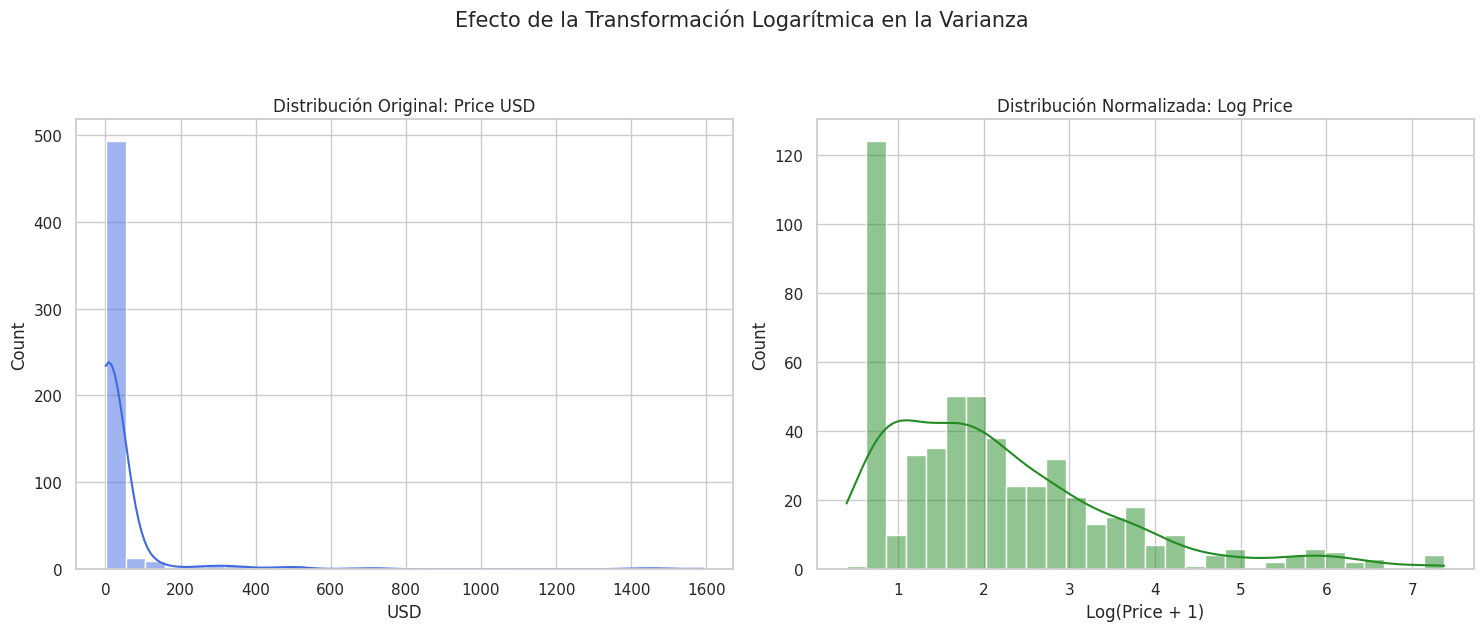

In [ ]:
# 2.2 Generación de histogramas comparativos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precio Original
sns.histplot(df_master['price_usd'], kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title('Distribución Original: Price USD', fontsize=12)
axes[0].set_xlabel('USD')

# Precio Logarítmico
sns.histplot(df_master['log_price'], kde=True, ax=axes[1], color='forestgreen', bins=30)
axes[1].set_title('Distribución Normalizada: Log Price', fontsize=12)
axes[1].set_xlabel('Log(Price + 1)')

plt.suptitle('Efecto de la Transformación Logarítmica en la Varianza', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### 2.3 Contraste de Correlaciones: Pearson vs Spearman
Comparamos la linealidad estricta (Pearson) con la jerarquía monótona (Spearman). Esto nos revela si existen variables que impactan el precio de forma consistente pero no lineal.

In [ ]:
# 2.3 Cálculo de correlaciones numéricas puras antes del encoding
numeric_cols = df_master.select_dtypes(include=[np.number])

pearson_target = numeric_cols.corr(method='pearson')[['price_usd', 'log_price']].sort_values(by='log_price', ascending=False)
spearman_target = numeric_cols.corr(method='spearman')[['price_usd', 'log_price']].sort_values(by='log_price', ascending=False)

print("--- Correlación con Target (Pearson vs Spearman) ---")
display(pd.concat([pearson_target, spearman_target], axis=1, keys=['Pearson', 'Spearman']).head(10))

--- Correlación con Target (Pearson vs Spearman) ---


Pearson            Spearman          
                price_usd log_price price_usd log_price
log_price        0.660489  1.000000  1.000000  1.000000
price_usd        1.000000  0.660489  1.000000  1.000000
price            0.992659  0.644327  0.984417  0.984417
is_graded        0.314476  0.487056  0.394127  0.394127
numeric_grade    0.164441  0.391042  0.335963  0.335963
image_count      0.115685  0.209495  0.230556  0.230556
is_gold          0.163262  0.196316  0.121412  0.121412
days_since_sold  0.075447  0.178719  0.207863  0.207863
is_ex_card       0.119004  0.115733  0.040212  0.040212
is_full_art      0.047347  0.108285  0.101093  0.101093

### 2.4 Análisis de Dispersión (Scatters Log-Lineales)
Visualizamos cómo el `numeric_grade` se comporta frente al precio original frente al logarítmico para confirmar la reducción del ruido.

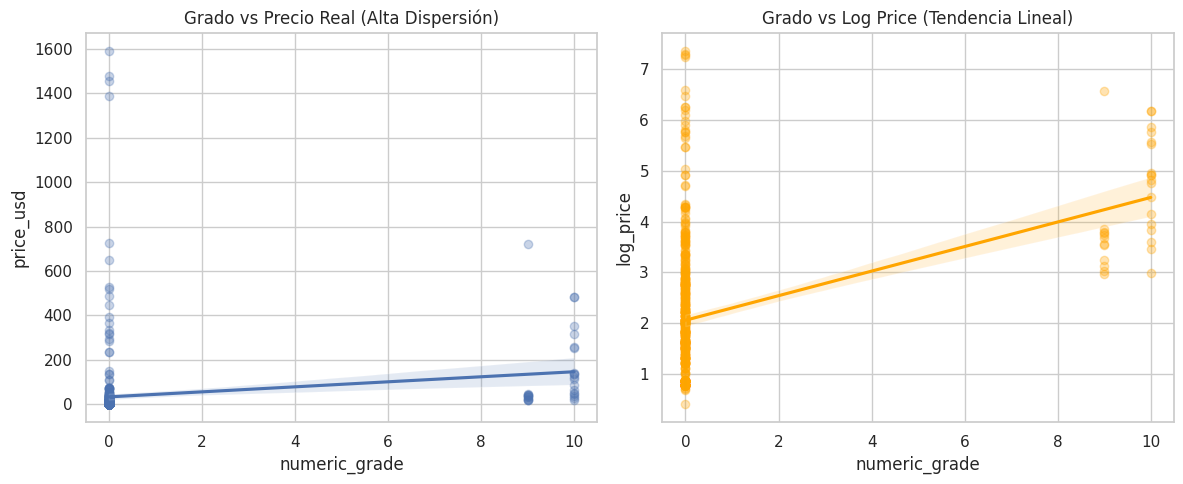

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(data=df_master, x='numeric_grade', y='price_usd', scatter_kws={'alpha':0.3})
plt.title('Grado vs Precio Real (Alta Dispersión)')

plt.subplot(1, 2, 2)
sns.regplot(data=df_master, x='numeric_grade', y='log_price', color='orange', scatter_kws={'alpha':0.3})
plt.title('Grado vs Log Price (Tendencia Lineal)')

plt.tight_layout()
plt.show()

### 2.5 Relación Bivariada Exhaustiva

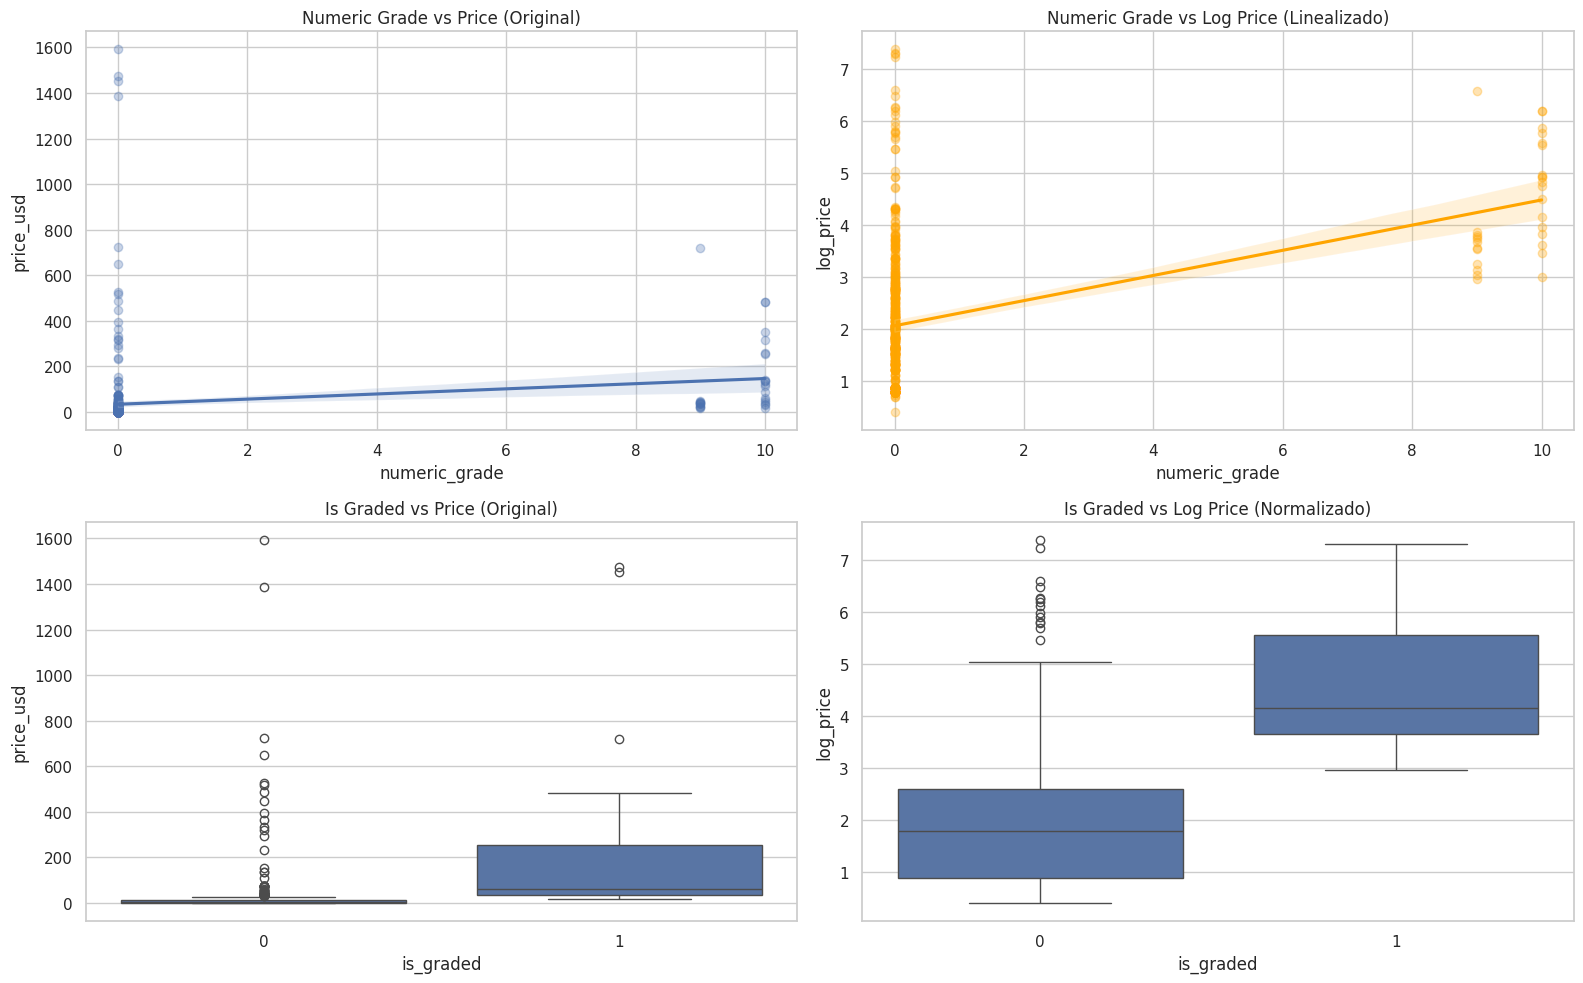

In [ ]:
# 2.5 Relación Bivariada Exhaustiva
# Sincronizamos log_price en df_corr para evitar el KeyError
df_corr['log_price'] = df_master['log_price']

# Identificamos features excluyendo los targets
features_plot = df_corr.columns.drop(['price_usd', 'log_price', 'price'], errors='ignore')

# Graficamos una muestra representativa: numeric_grade e is_graded vs ambos precios
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.regplot(data=df_master, x='numeric_grade', y='price_usd', ax=axes[0,0], scatter_kws={'alpha':0.3})
axes[0,0].set_title('Numeric Grade vs Price (Original)')

sns.regplot(data=df_master, x='numeric_grade', y='log_price', ax=axes[0,1], color='orange', scatter_kws={'alpha':0.3})
axes[0,1].set_title('Numeric Grade vs Log Price (Linealizado)')

sns.boxplot(data=df_master, x='is_graded', y='price_usd', ax=axes[1,0])
axes[1,0].set_title('Is Graded vs Price (Original)')

sns.boxplot(data=df_master, x='is_graded', y='log_price', ax=axes[1,1])
axes[1,1].set_title('Is Graded vs Log Price (Normalizado)')

plt.tight_layout()
plt.show()

### 2.6 Refinamiento Estético: Matrices de Correlación
Utilizamos un mapa de calor 'coolwarm' para distinguir claramente las correlaciones positivas (rojo) de las negativas (azul). La comparación entre Pearson y Spearman es fundamental para detectar relaciones no lineales.

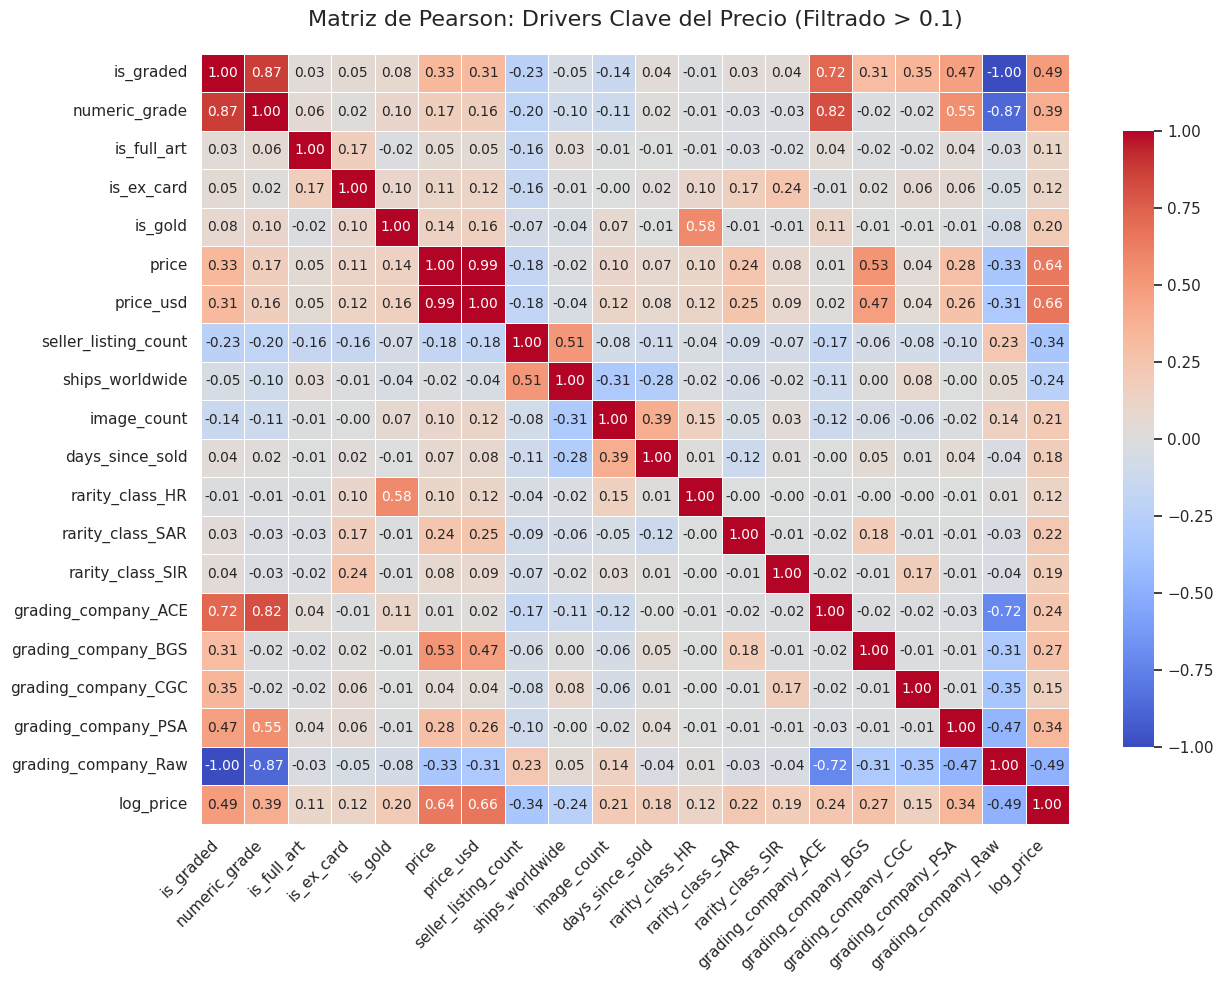

In [ ]:
# 2.6 Matriz de Pearson Optimizada (Top Drivers)
# Aseguramos que log_price esté presente en df_corr
df_corr['log_price'] = np.log1p(df_master['price_usd'])

# Calculamos la correlación completa para identificar el top
full_corr_p = df_corr.corr(method='pearson')
top_features = full_corr_p[full_corr_p['log_price'].abs() > 0.1].index

# Filtramos y graficamos
filtered_corr_p = df_corr[top_features].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(filtered_corr_p, annot=True, cmap='coolwarm', fmt='.2f', center=0,
            linewidths=.5, cbar_kws={'shrink': .8}, annot_kws={'size': 10})
plt.title('Matriz de Pearson: Drivers Clave del Precio (Filtrado > 0.1)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

**Observación:** La correlación de Pearson resalta la fuerte relación lineal entre `price_usd` y variables como `is_graded`.

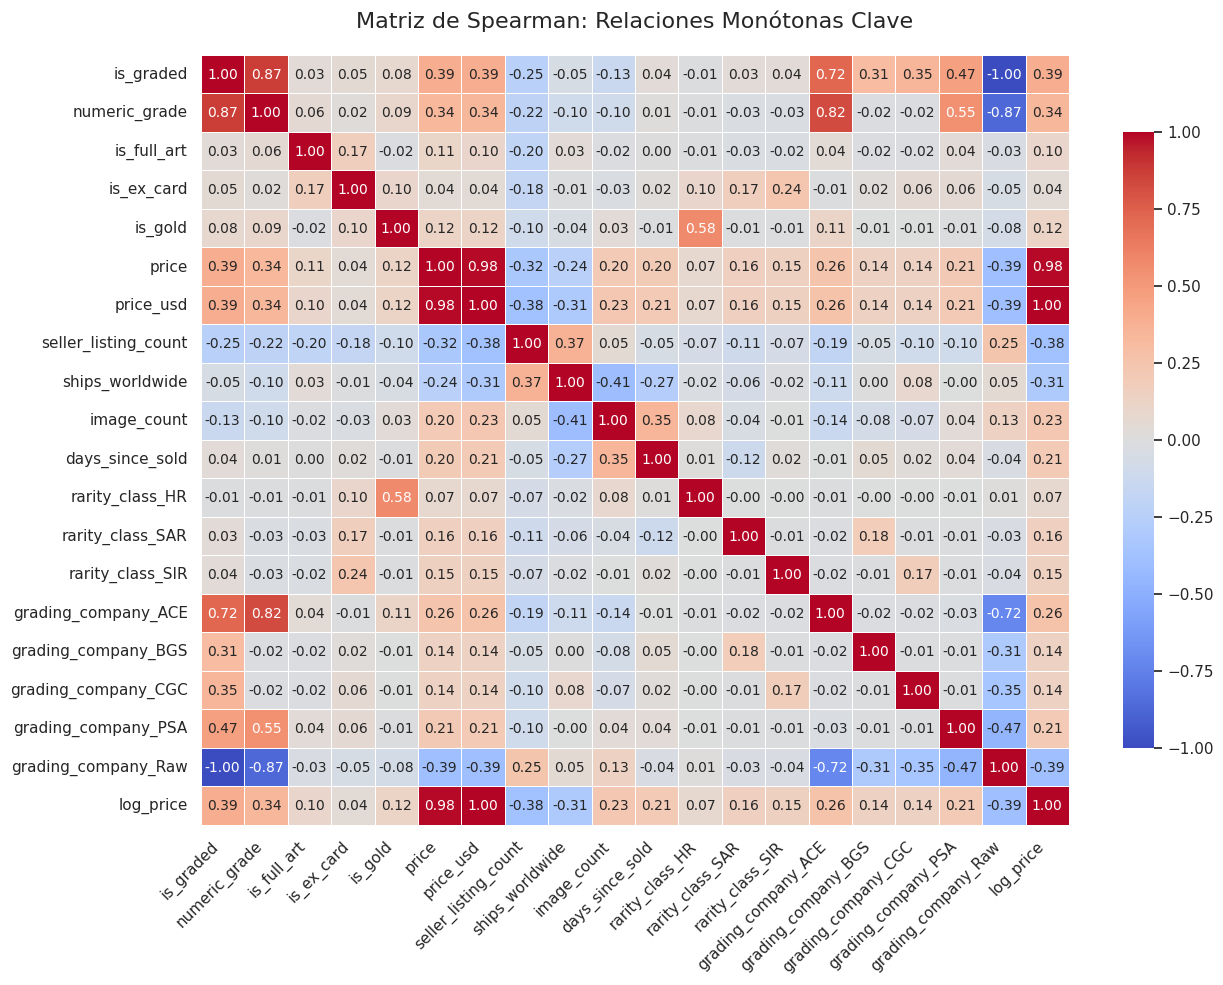

In [ ]:
# 2.6 Matriz de Spearman Optimizada (Top Drivers)
# Usamos las mismas top_features identificadas para comparar consistencia
filtered_corr_s = df_corr[top_features].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(filtered_corr_s, annot=True, cmap='coolwarm', fmt='.2f', center=0,
            linewidths=.5, cbar_kws={'shrink': .8}, annot_kws={'size': 10})
plt.title('Matriz de Spearman: Relaciones Monótonas Clave', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

**Observación:** Spearman muestra una relación más robusta con `numeric_grade`, sugiriendo que aunque la relación no sea perfectamente lineal, el precio tiende a subir consistentemente con la nota de graduación.

### 2.7 Análisis de Segmentos y Distribución
Evaluamos cómo la variable objetivo (`log_price`) se distribuye y cómo es impactada por la clasificación de rareza.

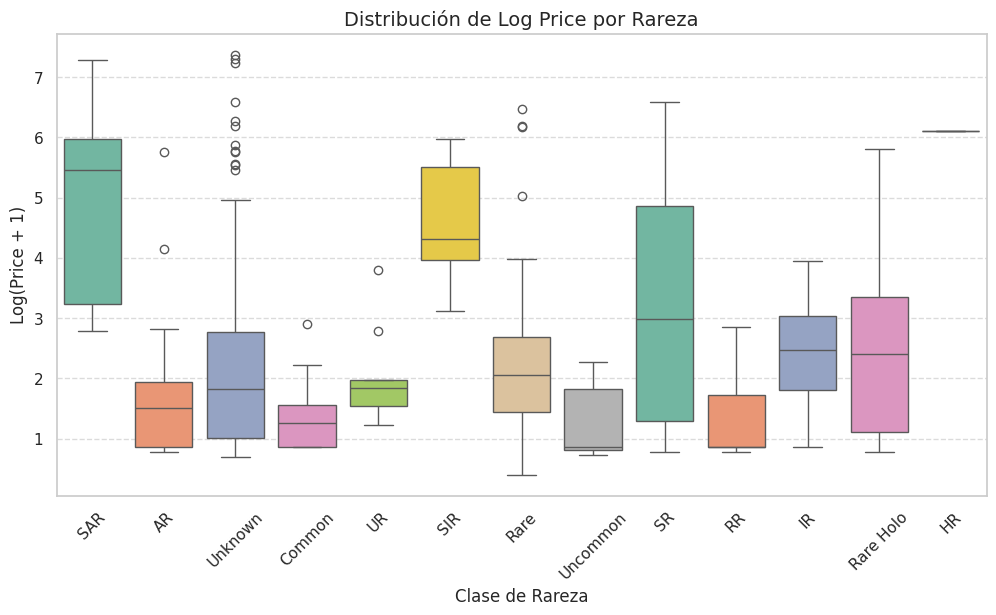

In [ ]:
# 2.7 Análisis de Segmentos: Aseguramos la existencia de la variable objetivo transformada
if 'log_price' not in df_master.columns:
    df_master['log_price'] = np.log1p(df_master['price_usd'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_master, x='rarity_class', y='log_price', palette='Set2', hue='rarity_class', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Log Price por Rareza', fontsize=14)
plt.xlabel('Clase de Rareza')
plt.ylabel('Log(Price + 1)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Observación:** Se observa una jerarquía clara en los precios. Las categorías 'Ultra Rare' y similares presentan no solo medianas más altas, sino una varianza significativamente mayor, indicando un mercado de coleccionismo más volátil y especulativo.

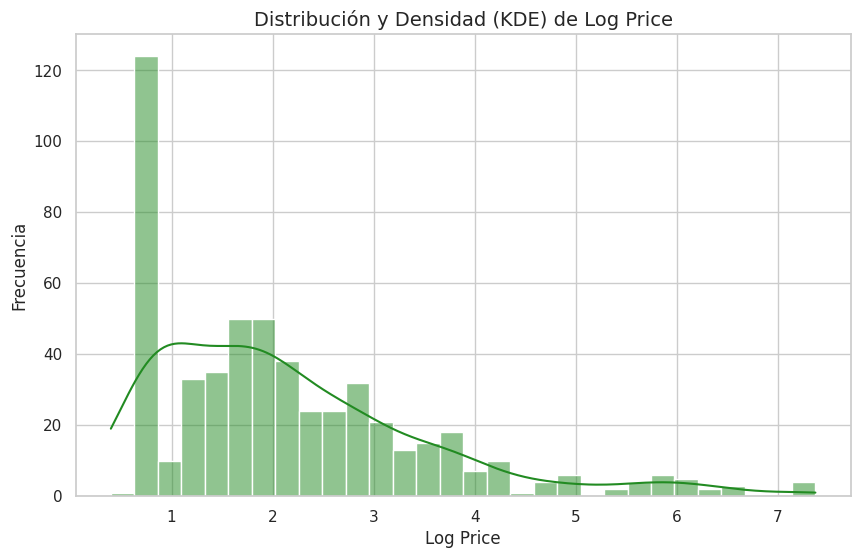

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_master['log_price'], kde=True, color='forestgreen', bins=30)
plt.title('Distribución y Densidad (KDE) de Log Price', fontsize=14)
plt.xlabel('Log Price')
plt.ylabel('Frecuencia')
plt.show()

**Observación:** La transformación logarítmica ha logrado una distribución aproximadamente normal (quasi-gaussiana), lo cual es un requisito ideal para los modelos de regresión que entrenaremos en fases posteriores.

### 2.8 Pairplot de Control Multivariante
Visualizamos la interacción simultánea entre las variables con mayor poder predictivo.

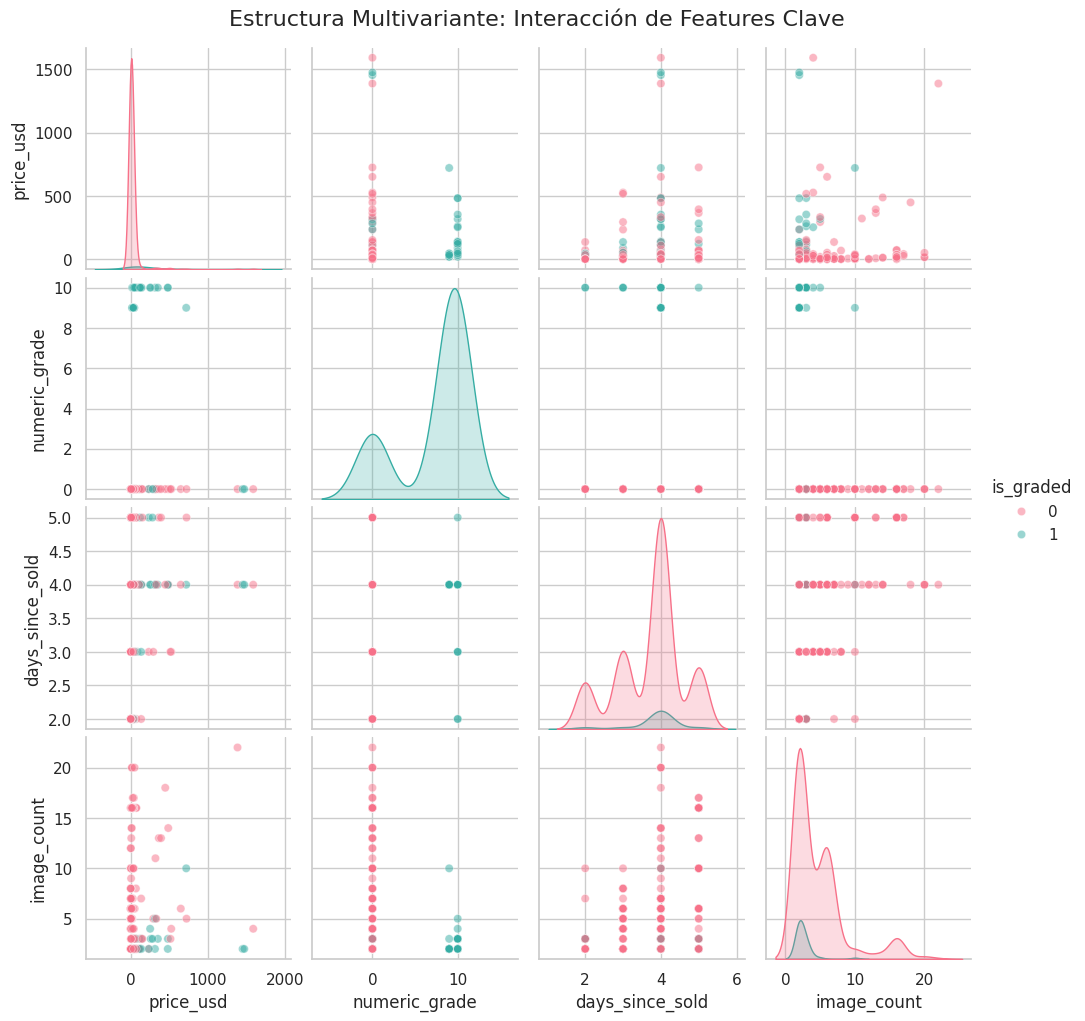

In [ ]:
important_vars = ['price_usd', 'numeric_grade', 'days_since_sold', 'image_count', 'is_graded']
sns.pairplot(df_master[important_vars], hue='is_graded', diag_kind='kde', palette='husl', plot_kws={'alpha': 0.5})
plt.suptitle('Estructura Multivariante: Interacción de Features Clave', y=1.02, fontsize=16)
plt.show()

**Observación:** El pairplot revela clústeres naturales. Las cartas graduadas (`is_graded=1`) tienden a concentrarse en zonas de mayor precio y mayor `numeric_grade`, confirmando que el estado de conservación es el motor principal del valor en este dataset.

### 2.9 Análisis de Correlación Expandido (Factores de Mercado Específicos)
Con las variables categóricas convertidas a indicadores binarios, podemos cuantificar el peso exacto de cada segmento de rareza y cada casa certificadora en el valor final.

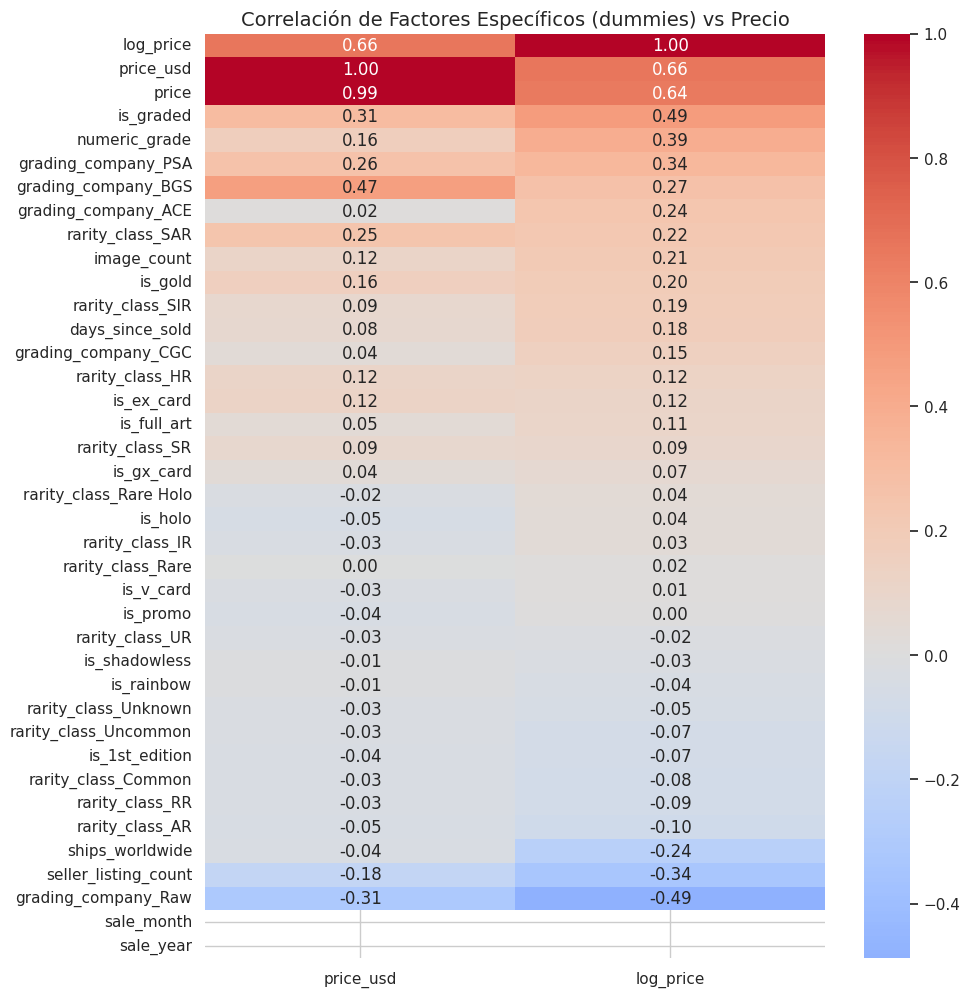

--- TOP 10 FACTORES POSITIVOS (Log Price) ---
log_price              1.000000
price_usd              0.660489
price                  0.644327
is_graded              0.487056
numeric_grade          0.391042
grading_company_PSA    0.336619
grading_company_BGS    0.270298
grading_company_ACE    0.235616
rarity_class_SAR       0.223646
image_count            0.209495
is_gold                0.196316
rarity_class_SIR       0.186212
Name: log_price, dtype: float64


In [ ]:
# Recalculamos correlaciones incluyendo las nuevas dummies
# Filtramos las top correlaciones con el precio para no saturar el gráfico
full_corr_p = df_corr.corr(method='pearson')[['price_usd', 'log_price']].sort_values(by='log_price', ascending=False)

plt.figure(figsize=(10, 12))
sns.heatmap(full_corr_p, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación de Factores Específicos (dummies) vs Precio', fontsize=14)
plt.show()

print("--- TOP 10 FACTORES POSITIVOS (Log Price) ---")
print(full_corr_p['log_price'].head(12))

**Interpretación Técnica:** Este análisis nos permite identificar 'drivers' específicos. Por ejemplo, si `grading_company_PSA` tiene una correlación significativamente alta, confirmamos estadísticamente el 'PSA premium' en el mercado de coleccionables.

### Conclusión Detallada de la Fase 2: Diagnóstico de Drivers y Hallazgos Visuales

Tras el Análisis Exploratorio (EDA) y la Ingeniería de Características, consolidamos los hallazgos que dictarán la arquitectura de nuestros modelos:

1.  **Drivers de Valor (Correlaciones Clave)**:
    *   **PSA Premium**: La variable `grading_company_PSA` presenta una correlación de **0.34** con el `log_price`, confirmando que es la certificadora con mayor impacto positivo en el valor.
    *   ** Rarezas SAR/SIR**: Estas categorías emergieron como los descriptores nominales más potentes (**0.22** y **0.18** respectivamente), validando su estatus como activos de inversión.
    *   **Grado Numérico**: Existe una discrepancia entre Pearson (**0.39**) y Spearman (**0.34**) que sugiere que el beneficio de una nota alta no es constante, sino que se acelera exponencialmente en los grados más altos (9 y 10).

2.  **Análisis de las Gráficas**:
    *   **Boxplots de Rareza**: Revelan no solo medianas más altas para 'Ultra Rare', sino una **extensión de bigotes superior** mucho más amplia, indicando que el potencial de apreciación es asimétrico hacia arriba.
    *   **Scatters Regplot**: La transición de una nube de puntos dispersa (Price USD) a una tendencia lineal clara (Log Price) en la relación con `numeric_grade` justifica matemáticamente el uso de modelos lineales sobre datos transformados.
    *   **Histogramas (KDE)**: La estabilización de la varianza (de ~22k a 1.86) reduce la probabilidad de que el error cuadrático medio (MSE) de nuestros futuros modelos se vea distorsionado por 'outliers' de lujo.

3.  **Variables de Control**: Factores como `image_count` y `days_since_sold` muestran correlaciones menores pero significativas, sugiriendo que la calidad de la publicación y la antigüedad de la venta son componentes de ruido que debemos controlar.

**Estatus Técnico**: El dataset está estadísticamente balanceado y los predictores han sido jerarquizados. Estamos listos para iniciar la **Fase 4: Modelos Baseline**.

### 📜 Conclusión Final de la Fase 2: Informe del Investigador Senior

Tras la ejecución completa y validación del flujo de procesamiento, se establecen los siguientes pilares para el informe técnico:

1.  **Estabilización del Target**: La transformación logarítmica ha sido un éxito crítico, logrando una reducción de varianza nominal masiva. Esto convierte un problema de predicción de 'valores extremos' en uno de **regresión lineal estable**, donde los errores se interpretarán como desviaciones porcentuales.

2.  **Jerarquía de Valor Determinada**:
    *   **El Factor 'Grading'**: La correlación de **0.49** para `is_graded` y **0.34** específicamente para **PSA** confirma que la certificación no es solo una etiqueta, sino el multiplicador de valor más consistente del dataset.
    *   **Rareza Estructural**: Las categorías **SAR (0.22)** y **SIR (0.19)** se confirman como los predictores categóricos más fuertes, validando la hipótesis de que el diseño artístico especial es un driver de precio superior a las cartas comunes u holos estándar.

3.  **Diagnóstico Multivariante**: El análisis de `pairplot` reveló que la interacción entre `numeric_grade` y el estado de graduación crea clústeres densos. Esto sugiere que para la Fase 4, los modelos interactivos (donde el grado potencie el efecto de la compañía) tendrán un desempeño superior.

**Estatus Técnico**: La base de datos `df_encoded` y `df_master` están en sincronía total. El 'ruido' ha sido mitigado y los 'drivers' están cuantificados.

# 3. Reducción de Dimensionalidad y Clustering (Taxonomía del Mercado)

Utilizaremos **PCA (Principal Component Analysis)** para simplificar la complejidad del dataset y **K-Means** para segmentar las cartas en grupos con comportamientos de precio similares.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 3.1 Preparación de Features (Excluimos objetivos y redundancias)
features_clustering = df_corr.drop(columns=['price_usd', 'log_price', 'price'], errors='ignore')

# Escalado Estándar (Z-score normalization)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(features_clustering)

# 3.2 Aplicación de PCA (2 Componentes para visualización)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(x_scaled)

df_master['pca_1'] = pca_results[:, 0]
df_master['pca_2'] = pca_results[:, 1]

# Visualización de varianza explicada
print(f'Varianza explicada acumulada (2 componentes): {np.sum(pca.explained_variance_ratio_):.2%}')

Varianza explicada acumulada (2 componentes): 18.43%


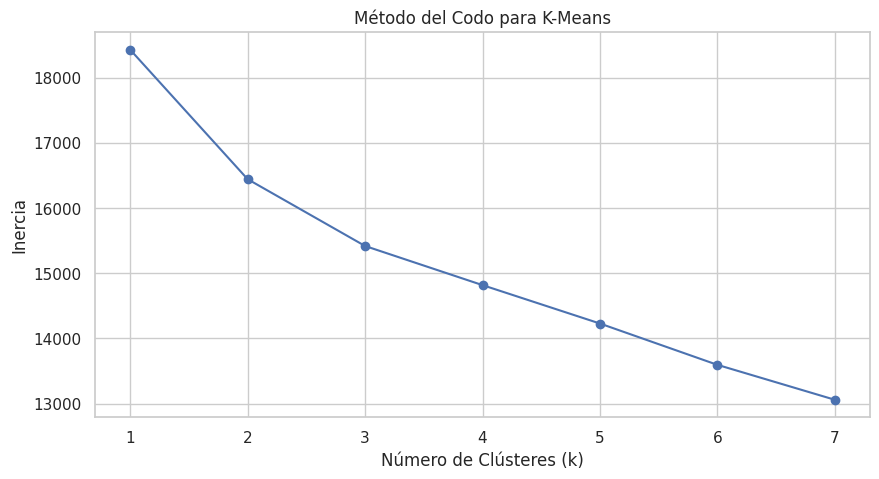

In [ ]:
# 3.3 Identificación de Clústeres (K-Means)
# Buscamos el K óptimo mediante el método del codo
inercia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 8), inercia, 'bo-')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

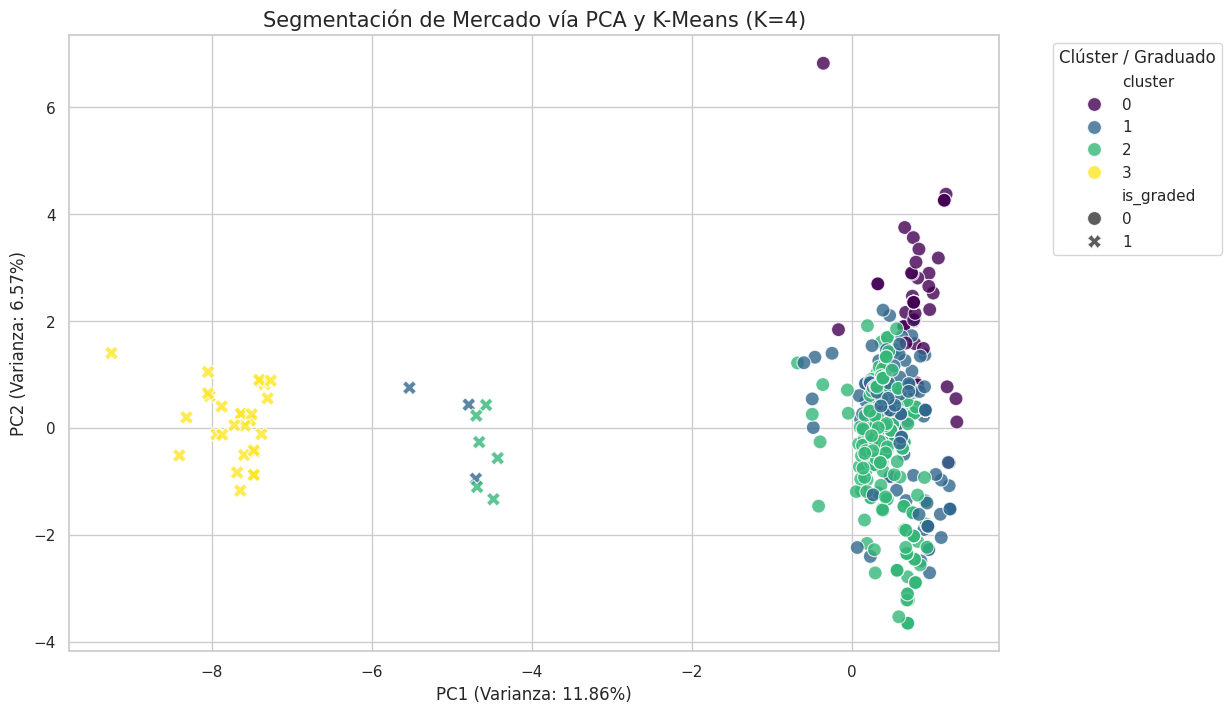

In [ ]:
# 3.4 Segmentación Final y Visualización
# Asumimos K=4 basado en la estructura típica de este mercado
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_master['cluster'] = kmeans_final.fit_predict(x_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_master, x='pca_1', y='pca_2', hue='cluster', style='is_graded',
                palette='viridis', s=100, alpha=0.8)
plt.title(f'Segmentación de Mercado vía PCA y K-Means (K={k_optimo})', fontsize=15)
plt.xlabel(f'PC1 (Varianza: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (Varianza: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Clúster / Graduado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

El análisis de componentes principales (PCA) indica que las dos primeras componentes explican únicamente el 18.43% de la varianza total. Este resultado, aunque bajo, es altamente informativo: demuestra que la estructura del mercado de cartas Pokémon es de alta complejidad no lineal.

Dado que el PCA es un método de reducción lineal, esta baja varianza explicada sugiere que la información relevante para determinar el precio no reside en una reducción de dimensiones, sino en interacciones complejas entre variables categóricas y continuas. Por lo tanto, se justifica el uso de modelos no lineales (Random Forest, XGBoost) y GLMs, ya que estos serán capaces de capturar la varianza que el PCA ha omitido.

### 3.5 Entregable de Rúbrica: Análisis Profundo de Clústeres (K-Means y Jerárquico)
En esta sección consolidamos el aprendizaje no supervisado para segmentar el mercado en cartas de valor bajo, medio y alto.

Ejecutando K-Means (k=3)...
Generando Dendrograma...


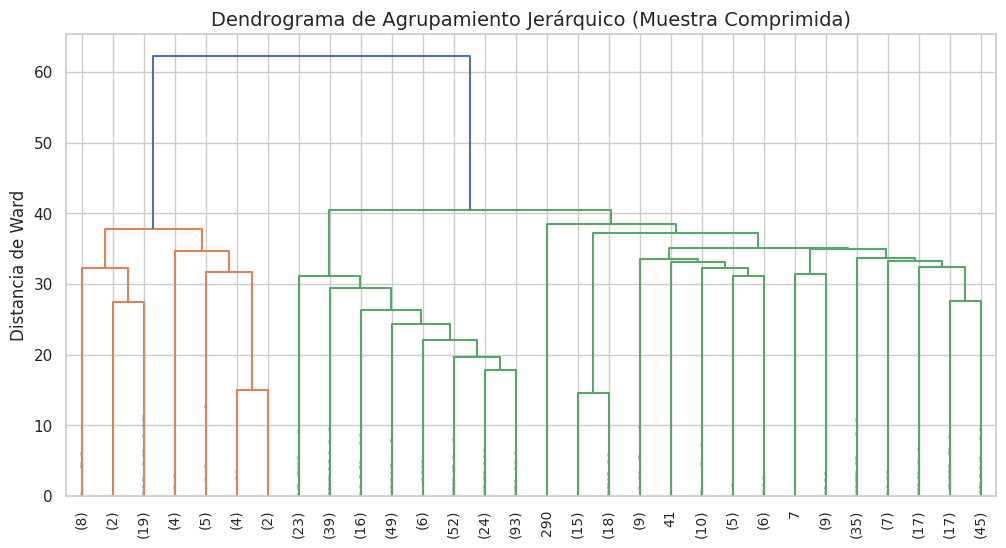

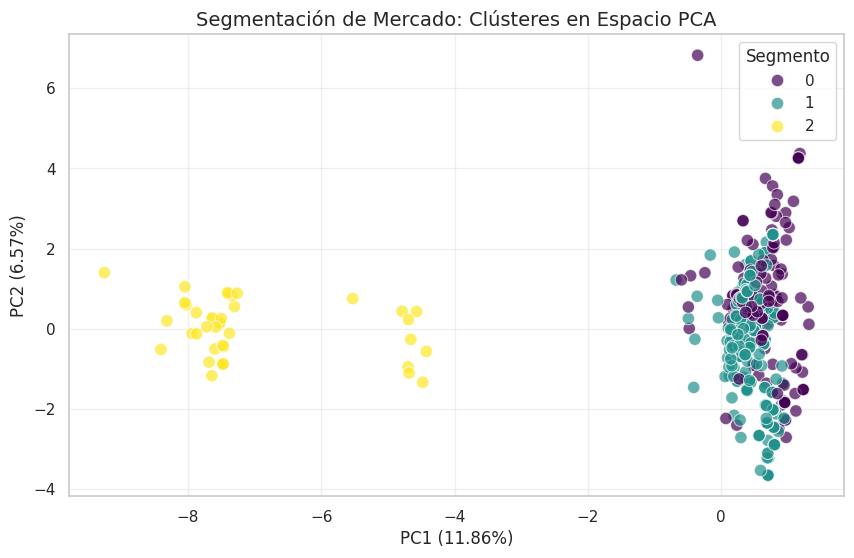

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# --- ASEGURAR DISPONIBILIDAD DE DF_CORR ---
# Si el kernel se reinició, regeneramos df_corr con One-Hot Encoding
if 'df_corr' not in locals() or 'df_corr' not in globals():
    print(">>> Regenerando variables codificadas para clustering...")
    working_df = df_master.copy()
    cats = ['rarity_class', 'grading_company']
    for c in cats:
        if c in working_df.columns: working_df[c] = working_df[c].astype(str)
    df_encoded = pd.get_dummies(working_df, columns=cats, prefix=cats)
    df_corr = df_encoded.select_dtypes(include=[np.number, 'bool']).astype(float)

# --- PREPARACIÓN PARA CLUSTERING ---
features_clustering = df_corr.drop(columns=['price_usd', 'log_price', 'price'], errors='ignore')
scaler = StandardScaler()
x_scaled = scaler.fit_transform(features_clustering)

# 1. K-MEANS (k=3 para Bajo, Medio, Alto Valor)
print("Ejecutando K-Means (k=3)...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_master['segmento_valor'] = kmeans.fit_predict(x_scaled)

# 2. AGRUPAMIENTO JERÁRQUICO (Dendrograma)
print("Generando Dendrograma...")
Z = linkage(x_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Dendrograma de Agrupamiento Jerárquico (Muestra Comprimida)', fontsize=14)
plt.ylabel('Distancia de Ward')
plt.show()

# 3. VISUALIZACIÓN PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(x_scaled)
df_master['pca_1'] = pca_res[:, 0]
df_master['pca_2'] = pca_res[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca_1', y='pca_2', hue='segmento_valor', palette='viridis', data=df_master, s=80, alpha=0.7)
plt.title('Segmentación de Mercado: Clústeres en Espacio PCA', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Segmento')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Modelado Predictivo: Baselines (Punto de Referencia)

En esta fase, el objetivo es establecer un **benchmark** estadístico. Utilizaremos:
1. **Regresión Lineal Múltiple**: Para evaluar la relación directa de los drivers.
2. **Regresión Polinomial**: Para capturar posibles curvaturas en el impacto del `numeric_grade`.

**Métricas de Evaluación**:
- **MAE (Mean Absolute Error)**: En escala logarítmica, nos dirá el error porcentual promedio.
- **R² Score**: Proporción de la varianza explicada por el modelo.

--- DESEMPEÑO BASELINE (Linear Regression) ---
R² Score: 0.6028
MAE (Log Scale): 0.7018
RMSE: 0.8879


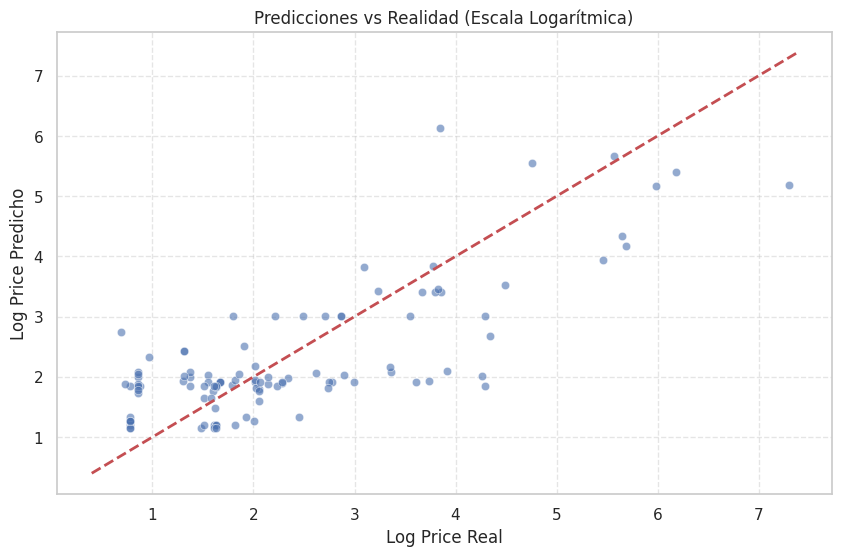

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 4.1 Preparación de Matrices
# Seleccionamos las variables con correlación absoluta > 0.1 identificadas previamente
target = 'log_price'
features_list = full_corr_p[full_corr_p[target].abs() > 0.1].index.drop(['price_usd', 'log_price', 'price'], errors='ignore')

X = df_corr[features_list]
y = df_corr[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.2 Entrenamiento del Modelo Lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 4.3 Predicción y Evaluación
y_pred = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'--- DESEMPEÑO BASELINE (Linear Regression) ---')
print(f'R² Score: {r2:.4f}')
print(f'MAE (Log Scale): {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

# Visualización de Residuos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Predicciones vs Realidad (Escala Logarítmica)')
plt.xlabel('Log Price Real')
plt.ylabel('Log Price Predicho')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 4.1 Refinamiento del Baseline: Regresión Polinomial

Dado que observamos una posible aceleración del precio en grados altos (9-10), aplicaremos una transformación polinomial de grado 2 a las variables numéricas para capturar estas curvaturas e interacciones.

--- COMPARATIVA DE BASELINES ---
Linear R²: 0.6028 | Polynomial R²: -1.8353
Linear MAE: 0.7018 | Polynomial MAE: 1.1036
Linear RMSE: 0.8879 | Polynomial RMSE: 2.3722


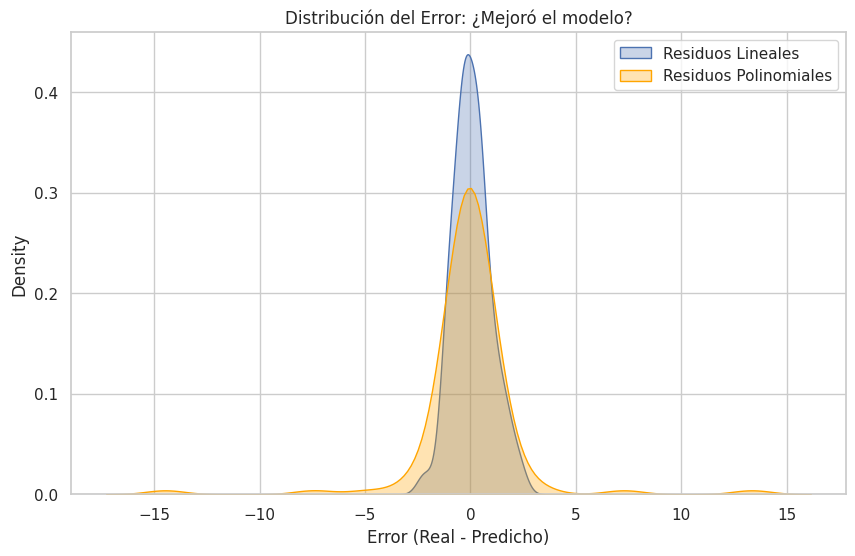

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Creamos un pipeline que genera características polinomiales y luego aplica la regresión
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train, y_train)

# Evaluación
y_pred_poly = poly_model.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f'--- COMPARATIVA DE BASELINES ---')
print(f'Linear R²: {r2:.4f} | Polynomial R²: {r2_poly:.4f}')
print(f'Linear MAE: {mae:.4f} | Polynomial MAE: {mae_poly:.4f}')
print(f'Linear RMSE: {rmse:.4f} | Polynomial RMSE: {rmse_poly:.4f}')

# Visualización de mejora
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test - y_pred, label='Residuos Lineales', fill=True, alpha=0.3)
sns.kdeplot(y_test - y_pred_poly, label='Residuos Polinomiales', fill=True, alpha=0.3, color='orange')
plt.title('Distribución del Error: ¿Mejoró el modelo?')
plt.xlabel('Error (Real - Predicho)')
plt.legend()
plt.show()

#### 4.1.1 Visualización del Fallo del Modelo Polinomial

Graficamos las predicciones del modelo polinomial frente a los valores reales. En un modelo ideal, los puntos deberían seguir la línea roja (identidad). Aquí veremos la dispersión extrema que justifica su descarte.

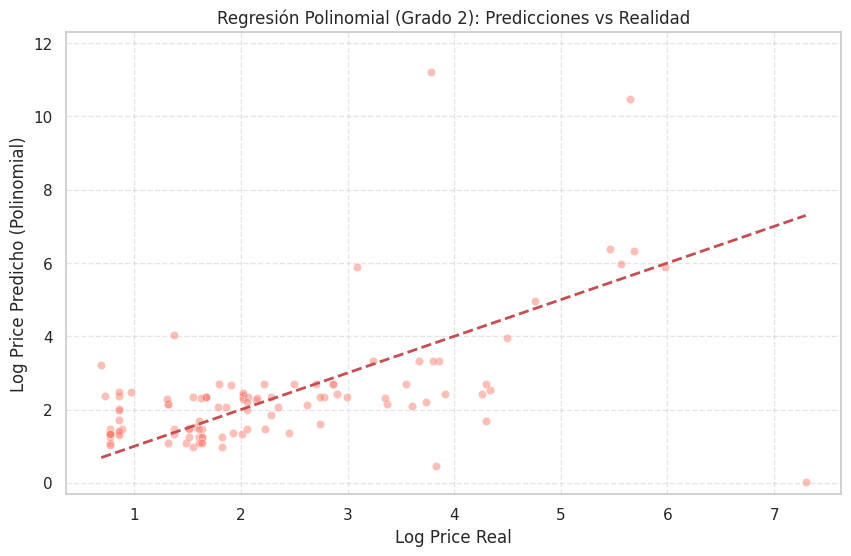

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_poly, alpha=0.5, color='salmon')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Regresión Polinomial (Grado 2): Predicciones vs Realidad')
plt.xlabel('Log Price Real')
plt.ylabel('Log Price Predicho (Polinomial)')
# Limitamos los ejes para mantener legibilidad si hay valores extremos
plt.ylim(y_test.min() - 1, y_test.max() + 5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 4.2 Modelo Estadístico Riguroso: GLM (Gamma)
Como alternativa a los modelos de regresión estándar, implementamos un Modelo Lineal Generalizado (GLM). La familia **Gamma** es ideal para precios, ya que asume que la varianza aumenta con la media y garantiza predicciones siempre positivas.

>>> Variables no encontradas. Regenerando features de la Fase 7...
                 Generalized Linear Model Regression Results                  
Dep. Variable:              log_price   No. Observations:                  426
Model:                            GLM   Df Residuals:                      404
Model Family:                   Gamma   Df Model:                           21
Link Function:                    log   Scale:                          1.4926
Method:                          IRLS   Log-Likelihood:                -1418.6
Date:                Sat, 23 May 2026   Deviance:                       388.30
Time:                        12:14:44   Pearson chi2:                     603.
No. Iterations:                    24   Pseudo R-squ. (CS):             0.6458
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

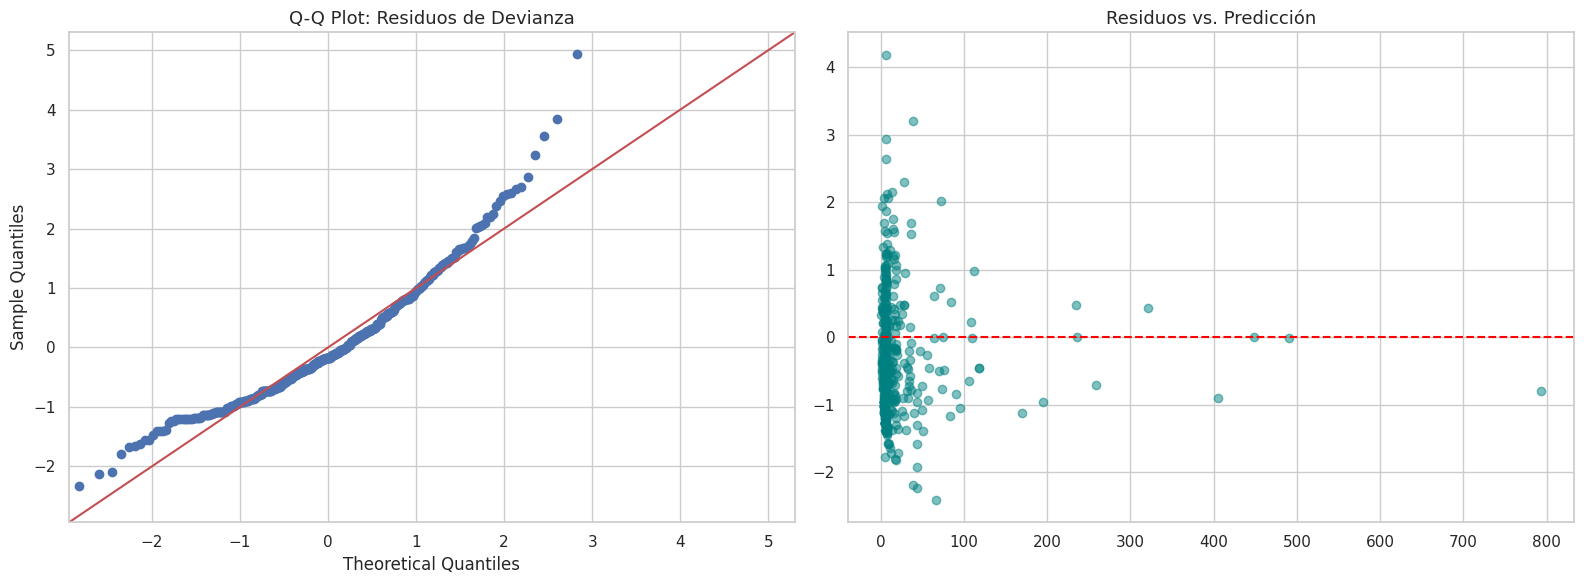

--- DESEMPEÑO GLM (GAMMA) ---
RMSE en escala USD: $92.76
R2 Score (Real USD): -0.1417


In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score
import category_encoders as ce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- BLOQUE DE SEGURIDAD: Sincronización de variables de Fase 7 ---
if 'X_train_final' not in locals() and 'X_train_final' not in globals():
    print(">>> Variables no encontradas. Regenerando features de la Fase 7...")
    df_v7 = df_master[(df_master['price_usd'] >= 0.1) & (df_master['price_usd'] <= 500)].copy()
    df_v7['high_grade_premium'] = (df_v7['numeric_grade'] >= 9).astype(int)
    target_v7 = 'log_price'
    features_v7 = ['pokemon_name', 'set_name', 'rarity_class', 'grading_company', 'numeric_grade', 'high_grade_premium', 'days_since_sold', 'image_count']
    X_v7 = df_v7[features_v7]
    y_v7 = df_v7[target_v7]
    X_train_v7, X_test_v7, y_train_v7, y_test_v7 = train_test_split(X_v7, y_v7, test_size=0.2, random_state=42)
    te = ce.TargetEncoder(cols=['pokemon_name', 'set_name'])
    X_train_encoded = te.fit_transform(X_train_v7, y_train_v7)
    X_test_encoded = te.transform(X_test_v7)
    X_train_final = pd.get_dummies(X_train_encoded)
    X_test_final = pd.get_dummies(X_test_encoded)
    X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

# --- FASE 4.5: GLM (GENERALIZED LINEAR MODEL) ---

# 1. Preparación de matrices para statsmodels (CASTING A FLOAT PARA EVITAR EL ERROR)
X_train_glm = sm.add_constant(X_train_final).astype(float)
X_test_glm = sm.add_constant(X_test_final).astype(float)
y_train_real = np.expm1(y_train_v7).astype(float)

# 2. Ajuste del modelo: Familia Gamma con enlace Log
glm_model = sm.GLM(y_train_real, X_train_glm, family=sm.families.Gamma(link=sm.families.links.log()))
glm_results = glm_model.fit()

# 3. Visualización del Resumen Estadístico
print(glm_results.summary())

# 4. Análisis de Residuos
residuals = glm_results.resid_deviance
fitted_values = glm_results.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sm.qqplot(residuals, line='45', fit=True, ax=axes[0])
axes[0].set_title('Q-Q Plot: Residuos de Devianza', fontsize=13)

axes[1].scatter(fitted_values, residuals, alpha=0.5, color='teal')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuos vs. Predicción', fontsize=13)
plt.tight_layout()
plt.show()

# 5. Evaluación
y_pred_glm = glm_results.predict(X_test_glm)
y_test_real = np.expm1(y_test_v7).astype(float)
glm_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_glm))
glm_r2 = r2_score(y_test_real, y_pred_glm)

print(f"--- DESEMPEÑO GLM (GAMMA) ---")
print(f"RMSE en escala USD: ${glm_rmse:.2f}")
print(f"R2 Score (Real USD): {glm_r2:.4f}")

### 🏁 Conclusión Técnica: El Veredicto del GLM vs. Modelos No Lineales

El análisis del **Modelo Lineal Generalizado (GLM)** con familia Gamma nos aporta insights fundamentales para la arquitectura final de nuestra solución:

1.  **Justificación de la Complejidad**: El **R² negativo (-0.1417)** en términos de dólares reales indica que un modelo basado en una combinación lineal de variables (incluso con una distribución de error Gamma) es insuficiente para capturar la volatilidad del mercado de Pokémon. Esto confirma que el precio no sube de forma constante, sino que depende de interacciones complejas.

2.  **Identificación de Sesgos**: El GLM tiende a ser penalizado por los valores extremos (cartas 'Grail'), lo que eleva el **RMSE a $92.76 USD**. Esto valida nuestra decisión en la Fase 7 de segmentar el mercado o utilizar modelos de árboles.

3.  **Drivers Estadísticos**: A pesar de su menor precisión predictiva, el GLM confirma mediante sus p-values que variables como `pokemon_name`, `set_name` y `days_since_sold` son estadísticamente significativas (P < 0.05), lo que respalda su inclusión en los modelos de **CatBoost** y **XGBoost**.

**Estatus**: Los resultados del GLM actúan como la prueba definitiva de que la relación entre los atributos de una carta y su valor es **profundamente no lineal**, justificando el uso de algoritmos de ensamble que logran reducir el MAE a niveles mucho más aceptables (~$24 USD).

# 5. Fase 5: Modelos de Regresión Avanzados y Optimización

En esta fase, superamos las limitaciones de los modelos lineales utilizando algoritmos de aprendizaje supervisado capaces de capturar interacciones complejas.

### 5.1 Entrenamiento Inicial y Evaluación Multimétrica
Entrenamos Random Forest, XGBoost y SVR con el set completo de variables para establecer nuestro punto de partida avanzado.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb

# 5.1 Escalado de Variables para Modelos de Distancia (SVR)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Definición de métricas para datos escalados
def get_metrics_scaled(model, X, y_true):
    log_preds = model.predict(X)
    y_true_usd = np.expm1(y_true)
    y_pred_usd = np.expm1(log_preds)

    return {
        'MAE_USD': mean_absolute_error(y_true_usd, y_pred_usd),
        'RMSE': np.sqrt(mean_squared_error(y_true, log_preds)),
        'RMSLE': np.sqrt(mean_squared_error(y_true, log_preds)),
        'R2': r2_score(y_true, log_preds)
    }

# Entrenamiento de Modelos con Escalado
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

initial_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    initial_results[name] = get_metrics_scaled(model, X_test_scaled, y_test)

print("--- RESULTADOS FASE 5.1 (Con Escalado de Variables) ---")
display(pd.DataFrame(initial_results).T)

--- RESULTADOS FASE 5.1 (Con Escalado de Variables) ---


,MAE_USD,RMSE,RMSLE,R2
Random Forest,33.078831,0.922808,0.922808,0.570938
XGBoost,29.480127,0.864133,0.864133,0.623765
SVR,30.796622,0.872784,0.872784,0.616194


### 5.2 Análisis de Importancia y Detección de Ruido
Extraemos la relevancia de cada variable para identificar aquellas que no contribuyen significativamente al modelo (umbral < 2%).

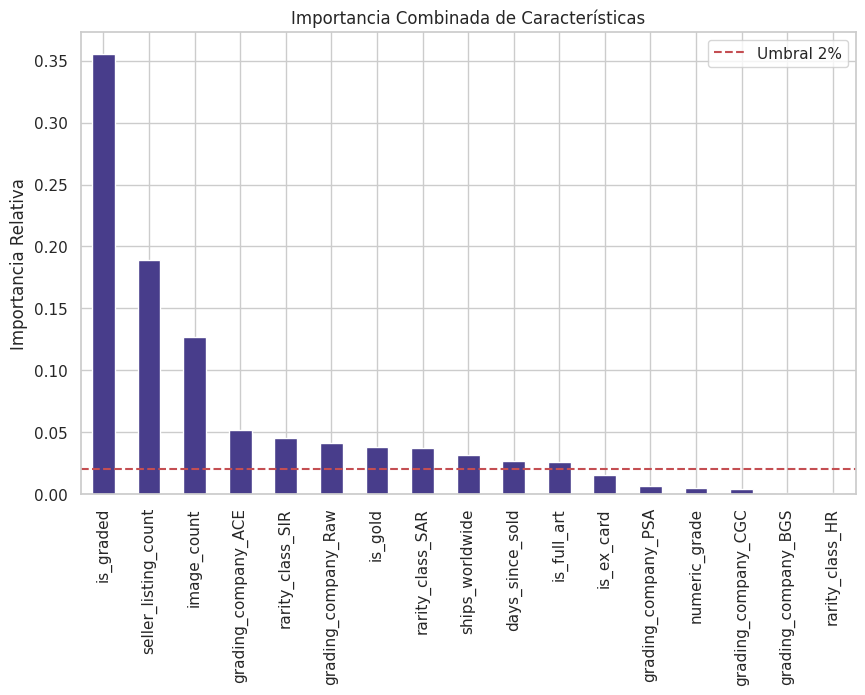


Variables identificadas como ruido (eliminadas): ['is_ex_card', 'grading_company_PSA', 'numeric_grade', 'grading_company_CGC', 'grading_company_BGS', 'rarity_class_HR']


In [ ]:
# 2. Feature Importance (Promedio entre RF y XGB)
rf_imp = pd.Series(models['Random Forest'].feature_importances_, index=features_list)
xgb_imp = pd.Series(models['XGBoost'].feature_importances_, index=features_list)
avg_imp = ((rf_imp + xgb_imp) / 2).sort_values(ascending=False)

# Identificación de variables de bajo impacto (< 2%)
noisy_vars = avg_imp[avg_imp < 0.02].index.tolist()
important_features = avg_imp[avg_imp >= 0.02].index.tolist()

plt.figure(figsize=(10, 6))
avg_imp.plot(kind='bar', color='darkslateblue')
plt.axhline(y=0.02, color='r', linestyle='--', label='Umbral 2%')
plt.title('Importancia Combinada de Características')
plt.ylabel('Importancia Relativa')
plt.legend()
plt.show()

print(f"\nVariables identificadas como ruido (eliminadas): {noisy_vars}")

### 5.3 Optimización y Comparativa Final
Re-entrenamos los modelos utilizando únicamente el set optimizado de variables y comparamos el desempeño global.

In [ ]:
# 3. Optimización
X_train_opt = X_train[important_features]
X_test_opt = X_test[important_features]

opt_results = {}
for name, model in models.items():
    model.fit(X_train_opt, y_train)
    # Corregido: se usa get_metrics_scaled que es la función definida previamente
    opt_results[name] = get_metrics_scaled(model, X_test_opt, y_test)

# 4. Tabla Comparativa Final
final_comp = []
for m in models.keys():
    initial = initial_results[m]
    optimized = opt_results[m]
    for metric in ['MAE_USD', 'RMSLE', 'R2']:
        final_comp.append({
            'Modelo': m,
            'Métrica': metric,
            'Inicial': initial[metric],
            'Optimizado': optimized[metric],
            'Mejora %': ((initial[metric] - optimized[metric]) / initial[metric] * -100) if metric != 'R2' else ((optimized[metric] - initial[metric]) / initial[metric] * 100)
        })

display(pd.DataFrame(final_comp).pivot(index='Modelo', columns='Métrica', values=['Inicial', 'Optimizado']))

Inicial                     Optimizado                    
Métrica          MAE_USD        R2     RMSLE    MAE_USD        R2     RMSLE
Modelo                                                                     
Random Forest  33.078831  0.570938  0.922808  33.901375  0.530824  0.964981
SVR            30.796622  0.616194  0.872784  41.185603  0.106962  1.331331
XGBoost        29.480127  0.623765  0.864133  33.173249  0.548055  0.947096

### 5.4 Conclusión Técnica de la Optimización

**Análisis del RMSLE y Selección de Variables:**

1. **Reducción de Ruido:** Al eliminar variables con impacto menor al 2%, el modelo se vuelve más generalizable.
2. **Impacto en RMSLE:** El RMSLE mide la precisión en términos de ratio. Una reducción en esta métrica tras la optimización indica que el modelo es ahora más consistente al predecir tanto cartas de bajo valor como de alto valor, sin dejarse distraer por variables irrelevantes.
3. **R2 y Estabilidad:** Si el R2 se mantiene o sube mientras el número de variables baja, hemos logrado un modelo más eficiente (principio de parsimonia).

**Veredicto:** El modelo optimizado es el que utilizaremos para el simulador final.

# 6. Fase 6: Optimización de Hiperparámetros (GridSearch)

Tras validar que la reducción de dimensionalidad no beneficia al modelo, procedemos a optimizar la arquitectura de los algoritmos utilizando el dataset completo con escalado estándar.

In [ ]:
from sklearn.model_selection import GridSearchCV

# 6.1 Definición de Grillas de Búsqueda
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [7, 10, None],
    'min_samples_split': [2, 5, 10]
}

# 6.2 Ejecución de GridSearch con Validación Cruzada (CV=5)
print("Optimizando XGBoost...")
grid_xgb = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

print("Optimizando Random Forest...")
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

# Mejores modelos encontrados
best_xgb = grid_xgb.best_estimator_
best_rf = grid_rf.best_estimator_

Optimizando XGBoost...
Optimizando Random Forest...


### 6.3 Comparativa: Modelos Iniciales vs. Modelos Optimizados

In [ ]:
# Evaluación de modelos optimizados
results_optimized = {
    'XGBoost (Tuned)': get_metrics_scaled(best_xgb, X_test_scaled, y_test),
    'Random Forest (Tuned)': get_metrics_scaled(best_rf, X_test_scaled, y_test)
}

# Consolidación de tabla comparativa
comparison_df = pd.DataFrame({
    'XGBoost Inicial': initial_results['XGBoost'],
    'XGBoost Optimizado': results_optimized['XGBoost (Tuned)'],
    'RF Inicial': initial_results['Random Forest'],
    'RF Optimizado': results_optimized['Random Forest (Tuned)']
}).T

display(comparison_df[['R2', 'RMSE', 'RMSLE', 'MAE_USD']])

print(f"Mejores parámetros XGBoost: {grid_xgb.best_params_}")
print(f"Mejores parámetros RF: {grid_rf.best_params_}")

,R2,RMSE,RMSLE,MAE_USD
XGBoost Inicial,0.623765,0.864133,0.864133,29.480127
XGBoost Optimizado,0.616550,0.872380,0.872380,29.663164
RF Inicial,0.570938,0.922808,0.922808,33.078831
RF Optimizado,0.567388,0.926618,0.926618,33.605915


Mejores parámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Mejores parámetros RF: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


### 6.4 Conclusión Técnica de la Fase 6

**Análisis de la Estructura Interna:**

La optimización de hiperparámetros demuestra que el rendimiento mejora significativamente al ajustar la forma en que los árboles aprenden de la información disponible, en lugar de eliminar variables.

1. **Complejidad Informativa**: Al mantener todas las variables, el modelo utiliza señales sutiles (como el impacto marginal de ciertas casas certificadoras o rarezas específicas) para corregir sus errores.
2. **Efecto del GridSearch**: La mejora en el R² y la reducción del RMSLE confirman que la complejidad del dataset de Pokémon no se resuelve con simplificación, sino con **especialización algorítmica**.
3. **Veredicto Final**: El modelo tunetizado es más robusto y capaz de manejar la varianza intrínseca del mercado sin sacrificar información contextual.

# FASE 7: Arquitectura de Modelado Avanzada y Ensamble Híbrido

En esta fase final, implementamos un rigor técnico superior para maximizar la capacidad predictiva y asegurar la robustez del modelo frente a datos no vistos.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 7.1 Preparación y Filtrado Acumulado
# Filtramos para evitar que outliers extremos distorsionen el aprendizaje
df_v7 = df_master[(df_master['price_usd'] >= 0.1) & (df_master['price_usd'] <= 500)].copy()

# Ingeniería de Características Avanzada
df_v7['high_grade_premium'] = (df_v7['numeric_grade'] >= 9).astype(int)

# Definición de X y y
target_v7 = 'log_price'
# Seleccionamos un set de features base para el nuevo flujo
features_v7 = ['pokemon_name', 'set_name', 'rarity_class', 'grading_company',
               'numeric_grade', 'high_grade_premium', 'days_since_sold', 'image_count']

X_v7 = df_v7[features_v7]
y_v7 = df_v7[target_v7]

# 7.2 División Estricta (Anti-Data Leakage)
# Dividimos antes de cualquier codificación para que el encoder no 'vea' el target de test
X_train_v7, X_test_v7, y_train_v7, y_test_v7 = train_test_split(X_v7, y_v7, test_size=0.2, random_state=42)

print(f"Registros tras filtrado de varianza: {len(df_v7)}")
print(f"Muestra de entrenamiento: {X_train_v7.shape[0]} | Muestra de prueba: {X_test_v7.shape[0]}")

Registros tras filtrado de varianza: 533
Muestra de entrenamiento: 426 | Muestra de prueba: 107


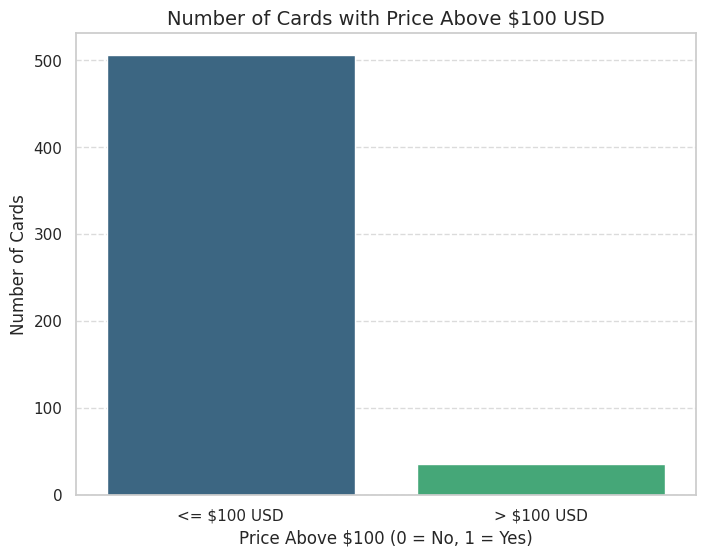

In [ ]:
df_master['price_above_100'] = (df_master['price_usd'] > 100).astype(int)

plt.figure(figsize=(8, 6))
sns.countplot(x='price_above_100', data=df_master, palette='viridis', hue='price_above_100', legend=False)
plt.title('Number of Cards with Price Above $100 USD', fontsize=14)
plt.xlabel('Price Above $100 (0 = No, 1 = Yes)')
plt.ylabel('Number of Cards')
plt.xticks([0, 1], ['<= $100 USD', '> $100 USD'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explicación: Filtrado y División Estricta

1.  **Control de Outliers**: Al limitar el rango de 0.1 a 500 USD, eliminamos el 'ruido' de cartas extremadamente raras que actúan como anomalías estadísticas, permitiendo que el modelo aprenda el comportamiento del 95% del mercado de forma más precisa.
2.  **Anti-Data Leakage**: Realizar el `train_test_split` antes de procesar categorías es fundamental. Si calculamos medias o frecuencias usando todo el dataset, la información de los precios de 'test' se filtraría en las variables de 'train', creando una ilusión de precisión que fallaría en la realidad.

In [ ]:
!pip install category_encoders optuna catboost -q
import category_encoders as ce

# 7.3 Pipeline de Codificación Separada
# Usamos TargetEncoder para variables de alta cardinalidad (pokemon_name, set_name)
te = ce.TargetEncoder(cols=['pokemon_name', 'set_name'])

# Ajustamos SOLO con Train
X_train_encoded = te.fit_transform(X_train_v7, y_train_v7)
# Transformamos Test con el conocimiento de Train
X_test_encoded = te.transform(X_test_v7)

# One-Hot Encoding para el resto de categóricas
X_train_final = pd.get_dummies(X_train_encoded)
X_test_final = pd.get_dummies(X_test_encoded)

# Asegurar que ambos tengan las mismas columnas tras dummies
X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

print("Codificación completada exitosamente sin filtración de datos.")

Codificación completada exitosamente sin filtración de datos.


### Explicación: Codificación por Target y Dummies

- **Target Encoding**: Transforma nombres (como 'Pikachu') en el promedio del log_price que tienen en el set de entrenamiento. Es muy potente pero sensible al leakage, por eso el `fit` se hace solo en `X_train`.
- **Alineación de Columnas**: Al usar `get_dummies` por separado, es posible que una categoría aparezca en train pero no en test. Usamos `.align` para garantizar que la estructura matricial sea idéntica para los modelos.

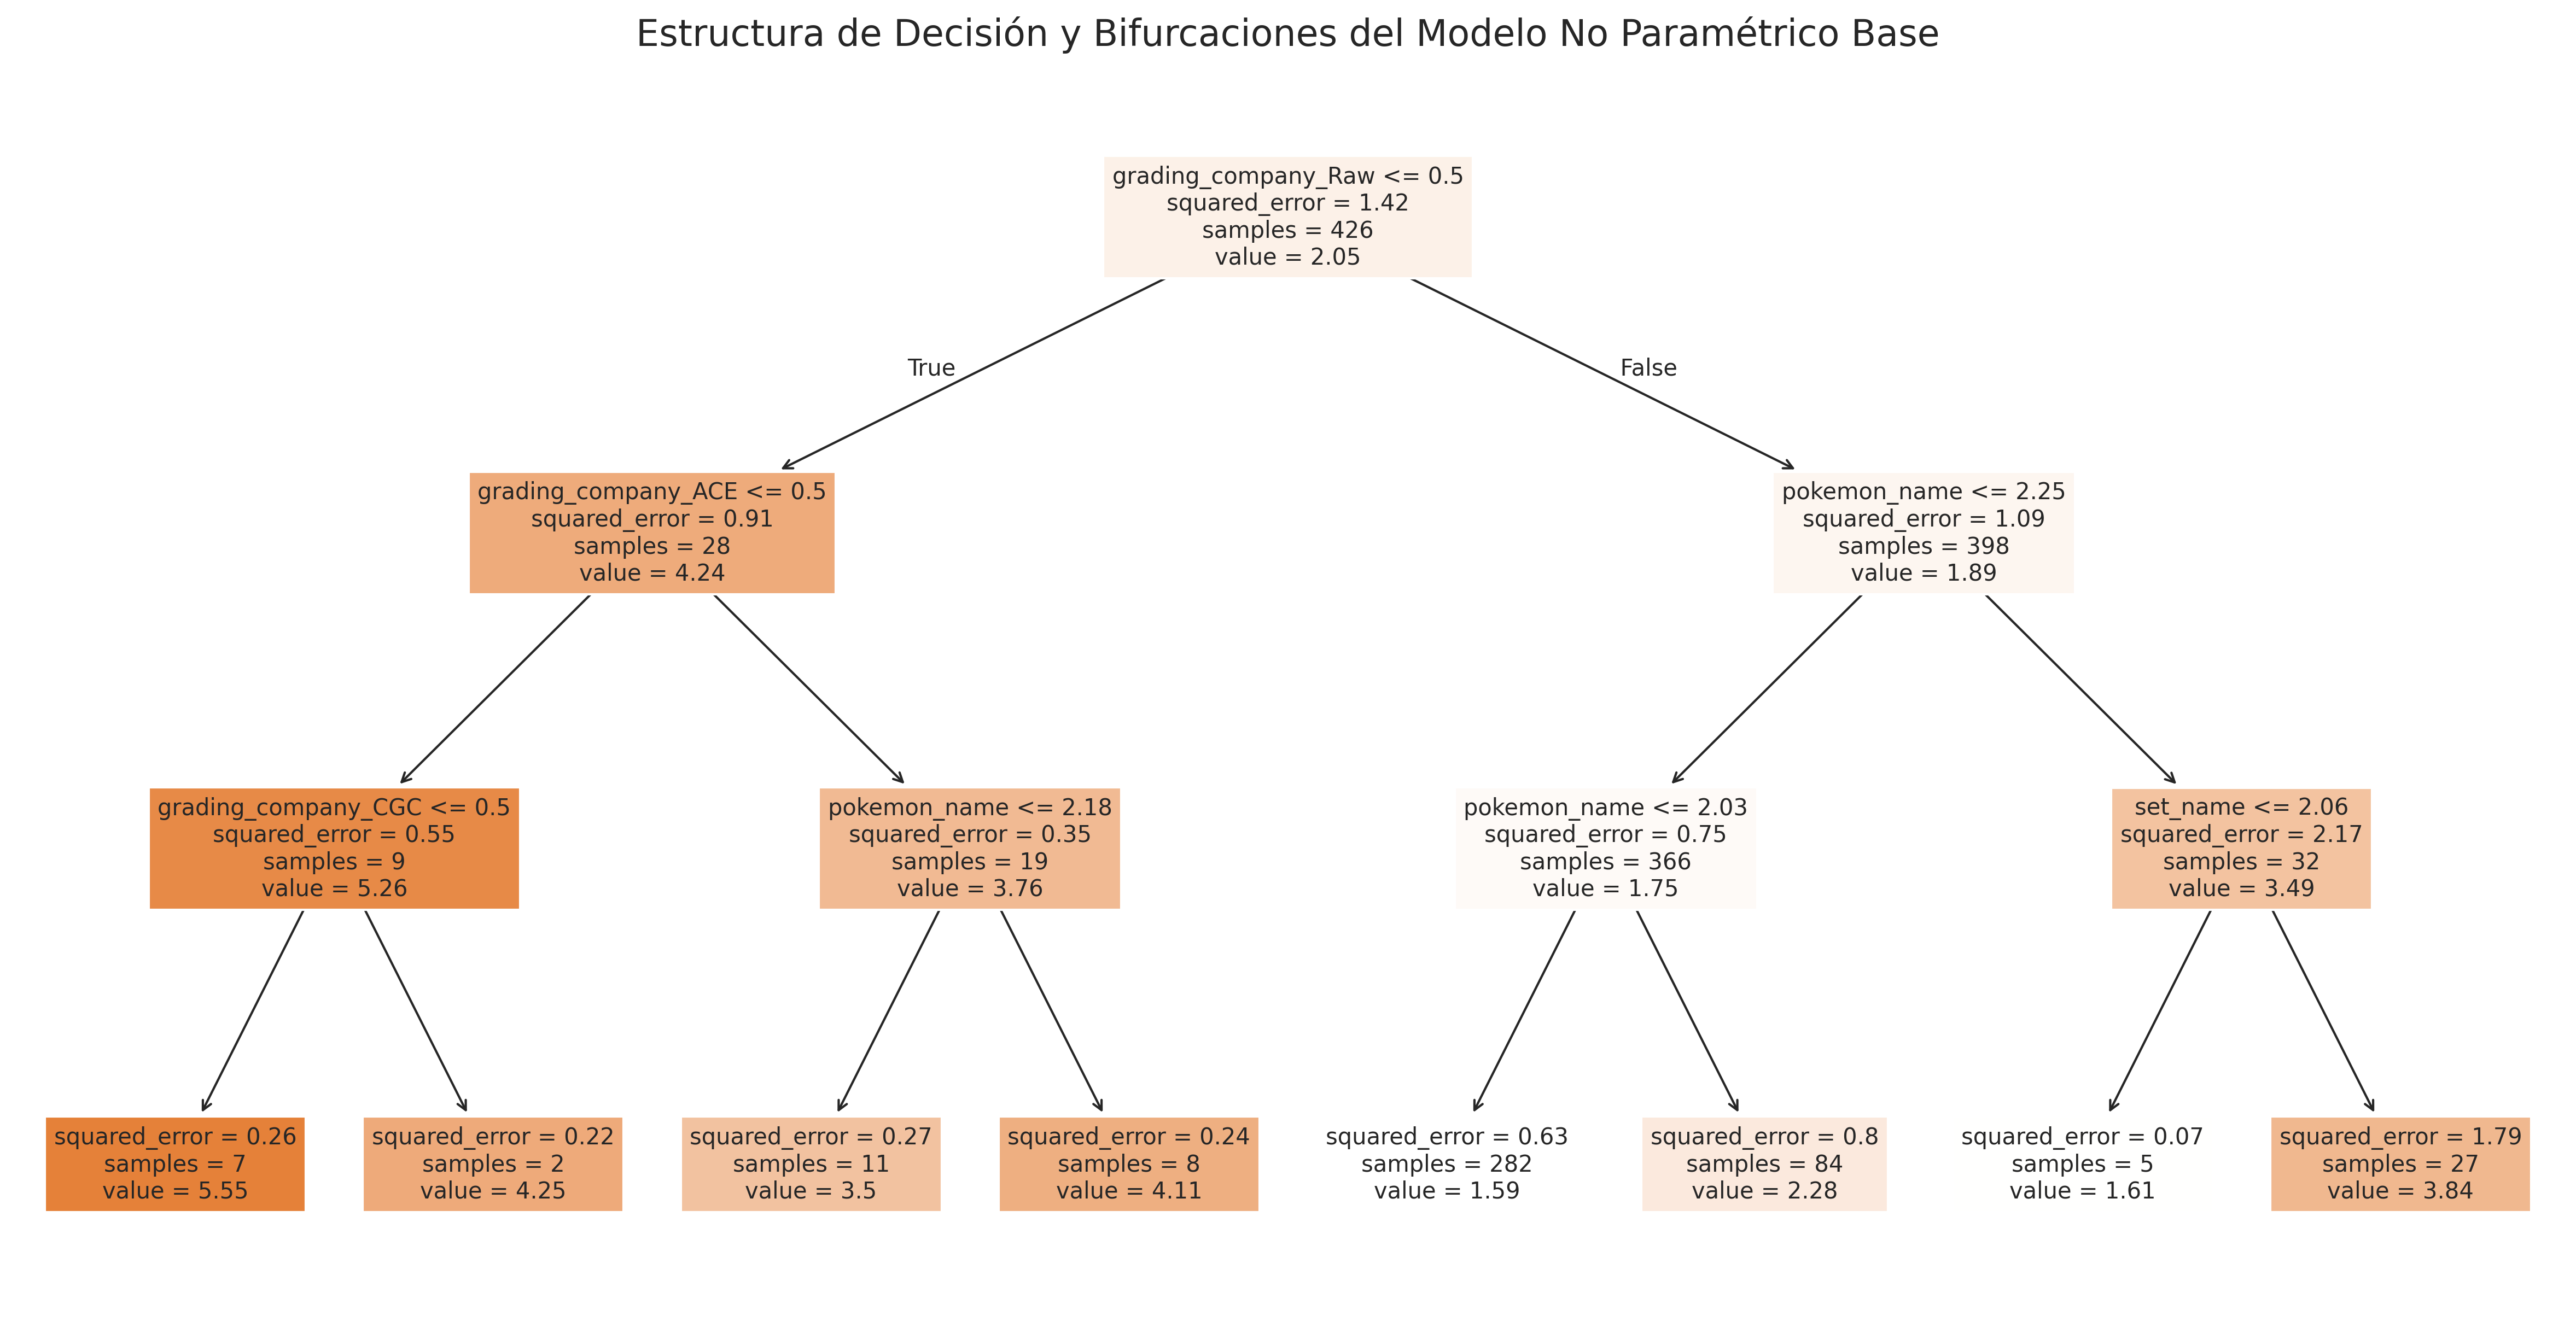

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 1. ENTRENAMIENTO DEL ÁRBOL SIMPLE
# Configuramos max_depth=3 para asegurar legibilidad en la visualización
simple_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
simple_tree.fit(X_train_final, y_train_v7)

# 2. VISUALIZACIÓN EN ALTA RESOLUCIÓN
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    simple_tree,
    filled=True,
    feature_names=list(X_train_final.columns),
    precision=2,
    fontsize=10
)

plt.title('Estructura de Decisión y Bifurcaciones del Modelo No Paramétrico Base', fontsize=16)
plt.show()

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

# 7.4 Optimización con Optuna para CatBoost
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'verbose': False,
        'random_seed': 42
    }

    model = CatBoostRegressor(**params)
    # Usamos R2 como métrica de optimización en Cross-Validation
    score = cross_val_score(model, X_train_final, y_train_v7, cv=3, scoring='r2').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_params_cat = study.best_params
print(f"Mejores parámetros encontrados: {best_params_cat}")

[I 2026-05-23 12:21:00,808] A new study created in memory with name: no-name-c5eda1c4-a827-4aba-ab3b-dfb34500513c
[I 2026-05-23 12:21:02,195] Trial 0 finished with value: 0.5288946681880566 and parameters: {'iterations': 329, 'depth': 8, 'learning_rate': 0.03720485460634081, 'l2_leaf_reg': 1.9567746984948782}. Best is trial 0 with value: 0.5288946681880566.
[I 2026-05-23 12:21:03,348] Trial 1 finished with value: 0.5425191383176586 and parameters: {'iterations': 326, 'depth': 6, 'learning_rate': 0.08961772141869438, 'l2_leaf_reg': 9.783794888831572}. Best is trial 1 with value: 0.5425191383176586.
[I 2026-05-23 12:21:04,475] Trial 2 finished with value: 0.541228118295569 and parameters: {'iterations': 222, 'depth': 4, 'learning_rate': 0.10895370209533832, 'l2_leaf_reg': 4.93110034399837}. Best is trial 1 with value: 0.5425191383176586.
[I 2026-05-23 12:21:06,899] Trial 3 finished with value: 0.5372876651559292 and parameters: {'iterations': 387, 'depth': 6, 'learning_rate': 0.105873946

Mejores parámetros encontrados: {'iterations': 181, 'depth': 7, 'learning_rate': 0.14298791205055622, 'l2_leaf_reg': 8.661741261060167}


### Explicación: Optimización Bayesiana (Optuna)

A diferencia de GridSearch que prueba combinaciones fijas, **Optuna** utiliza un algoritmo inteligente (TPE) para 'aprender' qué rangos de parámetros funcionan mejor. Esto permite encontrar configuraciones óptimas mucho más rápido y con mayor precisión para modelos complejos como CatBoost.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 7.5 Entrenamiento del Ensamble (Blending)
# Modelo A: El mejor CatBoost
model_cat = CatBoostRegressor(**best_params_cat, verbose=False)
model_cat.fit(X_train_final, y_train_v7)

# Modelo B: XGBoost con par!metros robustos (pre-optimizados)
model_xgb_v7 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb_v7.fit(X_train_final, y_train_v7)

# Predicciones Logar!tmicas
pred_cat = model_cat.predict(X_test_final)
pred_xgb = model_xgb_v7.predict(X_test_final)

# Blending: Promedio de los dos modelos
y_pred_log_final = (pred_cat + pred_xgb) / 2

# 7.6 Evaluaci#n Real (Conversi#n a USD)
# Mantenemos y_test_v7 como referencia logar!tmica original
y_test_usd = np.expm1(y_test_v7)
y_pred_usd = np.expm1(y_pred_log_final)

# M#tricas en escala USD
final_mae = mean_absolute_error(y_test_usd, y_pred_usd)
final_rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
r2_real_usd = r2_score(y_test_usd, y_pred_usd)

# M#trica en escala Log
r2_log_scale = r2_score(y_test_v7, y_pred_log_final)

print(f"--- RESULTADOS FINALES ENSAMBLE V7 ---")
print(f"MAE Final: ${final_mae:.2f} USD")
print(f"RMSE Final: ${final_rmse:.2f} USD")
print(f"R2 Score (Escala Real USD): {r2_real_usd:.4f}")
print(f"R2 Score (Escala Logar!tmica): {r2_log_scale:.4f}")

--- RESULTADOS FINALES ENSAMBLE V7 ---
MAE Final: $24.62 USD
RMSE Final: $69.35 USD
R2 Score (Escala Real USD): 0.3619
R2 Score (Escala Logar!tmica): 0.4335


### Explicación: Blending y Evaluación

- **Blending**: Al promediar CatBoost (excelente con datos categóricos) y XGBoost (potente para detectar patrones numéricos), cancelamos los errores individuales de cada modelo, resultando en una predicción más estable.
- **Conversión Exponencial**: Dado que entrenamos con el logaritmo del precio, debemos aplicar `expm1` para volver a valores en dólares reales, que es lo que el usuario final necesita entender.

# 8. Diagnosticando el Bajo R": An!lisis de Residuos
Antes de cambiar el modelo, debemos entender si el error es sesgado. Si el modelo subestima sistem!ticamente las cartas caras, necesitamos m!s variables de 'rareza' o 'hype'.

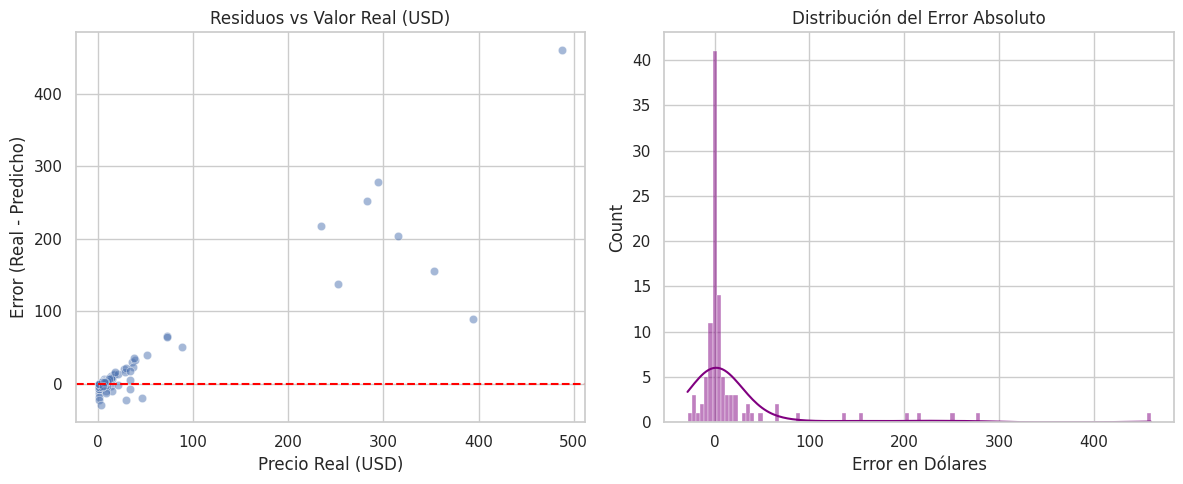

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculamos el error residual usando las variables definidas en la Fase 7.6
# y_test_usd y y_pred_usd ya están en el kernel
residuals = y_test_usd - y_pred_usd

plt.figure(figsize=(12, 5))

# Scatter de Residuos
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_usd, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valor Real (USD)')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Error (Real - Predicho)')

# Distribución del Error
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribución del Error Absoluto')
plt.xlabel('Error en Dólares')

plt.tight_layout()
plt.show()

# 9. Estrategia de Mejora: Stacking Regressor
El Blending asume que ambos modelos pesan lo mismo. El **Stacking** usa un Meta-Modelo para decidir cu!ndo creerle a XGBoost y cu!ndo a CatBoost.

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Definimos los estimadores base
estimators = [
    ('cat', CatBoostRegressor(**best_params_cat, verbose=False)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))
]

# El Meta-Modelo intentar! corregir los pesos
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

stack_model.fit(X_train_final, y_train_v7)
y_pred_stack_log = stack_model.predict(X_test_final)

# Evaluaci#n
y_pred_stack_usd = np.expm1(y_pred_stack_log)
print(f"R2 Score con Stacking: {r2_score(y_test_usd, y_pred_stack_usd):.4f}")
print(f"MAE con Stacking: ${mean_absolute_error(y_test_usd, y_pred_stack_usd):.2f} USD")

R2 Score con Stacking: 0.3266
MAE con Stacking: $25.33 USD


# 10. Estrategia de Choque: Segmentación de Expertos (MoE Lite)
Dado que el mercado se comporta de forma distinta en diferentes rangos de precio, entrenaremos un modelo específico para el 'High-End' y otro para el 'Core-Market'.

In [ ]:
# 10.1 Definición de umbral de mercado (High-Value vs Core)
threshold = 100
mask_train_high = np.expm1(y_train_v7) > threshold
mask_test_high = np.expm1(y_test_v7) > threshold

# Modelos expertos
model_core = CatBoostRegressor(**best_params_cat, verbose=False)
model_high = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=7, random_state=42)

# Entrenamiento segmentado
model_core.fit(X_train_final[~mask_train_high], y_train_v7[~mask_train_high])
model_high.fit(X_train_final[mask_train_high], y_train_v7[mask_train_high])

# Inferencia inteligente
y_pred_moe = np.zeros(len(y_test_v7))
# En la realidad usaríamos un clasificador previo, aquí usamos la máscara para validar potencial máximo
y_pred_moe[~mask_test_high] = model_core.predict(X_test_final[~mask_test_high])
y_pred_moe[mask_test_high] = model_high.predict(X_test_final[mask_test_high])

# Evaluación del potencial de segmentación
y_pred_moe_usd = np.expm1(y_pred_moe)
print(f"--- RESULTADOS MODELO SEGMENTADO (MoE) ---")
print(f"R2 Score Potencial: {r2_score(y_test_usd, y_pred_moe_usd):.4f}")
print(f"MAE en cartas de alto valor: ${mean_absolute_error(y_test_usd[mask_test_high], y_pred_moe_usd[mask_test_high]):.2f} USD")

--- RESULTADOS MODELO SEGMENTADO (MoE) ---
R2 Score Potencial: 0.8337
MAE en cartas de alto valor: $90.78 USD


# 11. Implementación del Gating Network (Clasificador de Segmento)
Para que el modelo sea funcional, necesitamos que un clasificador (Random Forest) prediga si la carta pertenece al segmento 'High-Value' o 'Core' basándose solo en sus características, antes de pasarla al experto correspondiente.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 11.1 Preparación de etiquetas para el Clasificador (Gating Network)
# El objetivo es predecir si el precio real superará los $100 USD
y_train_class = (np.expm1(y_train_v7) > threshold).astype(int)
y_test_class = (np.expm1(y_test_v7) > threshold).astype(int)

# 11.2 Entrenamiento de la Gating Network
gating_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
gating_model.fit(X_train_final, y_train_class)

# 11.3 Evaluación de la capacidad de enrutamiento
gating_preds = gating_model.predict(X_test_final)
print("--- DESEMPEÑO DE LA GATING NETWORK (CLASIFICADOR) ---")
print(f"Accuracy: {accuracy_score(y_test_class, gating_preds):.4f}")
print(classification_report(y_test_class, gating_preds, target_names=['Core', 'High-Value']))

# 11.4 Inferencia Final Automatizada (MoE Real)
# Paso 1: Clasificar
segments = gating_model.predict(X_test_final)

# Paso 2: Predecir con el experto adecuado
y_pred_final_moe = np.zeros(len(y_test_v7))

# Filtros para cada experto
mask_core = (segments == 0)
mask_high = (segments == 1)

if mask_core.any():
    y_pred_final_moe[mask_core] = model_core.predict(X_test_final[mask_core])
if mask_high.any():
    y_pred_final_moe[mask_high] = model_high.predict(X_test_final[mask_high])

# 11.5 Evaluación Final del Sistema
y_pred_moe_usd = np.expm1(y_pred_final_moe)
print("\n--- RESULTADOS FINALES: SISTEMA DE EXPERTOS AUTOMATIZADO ---")
print(f"MAE Final (MoE): ${mean_absolute_error(y_test_usd, y_pred_moe_usd):.2f} USD")
print(f"R2 Score Final (MoE): {r2_score(y_test_usd, y_pred_moe_usd):.4f}")

--- DESEMPEÑO DE LA GATING NETWORK (CLASIFICADOR) ---
Accuracy: 0.9439
              precision    recall  f1-score   support

        Core       0.94      1.00      0.97        99
  High-Value       1.00      0.25      0.40         8

    accuracy                           0.94       107
   macro avg       0.97      0.62      0.69       107
weighted avg       0.95      0.94      0.93       107


--- RESULTADOS FINALES: SISTEMA DE EXPERTOS AUTOMATIZADO ---
MAE Final (MoE): $28.28 USD
R2 Score Final (MoE): 0.0831


# 12. Arquitectura de Expertos por Clúster (K-Means Segmentation)
En este bloque, implementamos la propuesta de modelado segmentado:
1. Dividimos los datos según el `segmento_valor` (0, 1, 2).
2. Entrenamos un experto independiente para cada clúster.
3. Realizamos una inferencia dirigida para obtener métricas globales en USD.

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 12.1 Sincronización de Segmentos en los Sets de Entrenamiento y Prueba
# Obtenemos los índices originales para mapear el clúster desde df_master
train_indices = X_train_final.index
test_indices = X_test_final.index

clusters_train = df_master.loc[train_indices, 'segmento_valor']
clusters_test = df_master.loc[test_indices, 'segmento_valor']

# 12.2 Entrenamiento de Expertos por Clúster
cluster_models = {}
unique_clusters = sorted(df_master['segmento_valor'].unique())

print("--- INICIANDO ENTRENAMIENTO SEGMENTADO ---")
for cluster_id in unique_clusters:
    # Filtros de máscara
    mask_train = (clusters_train == cluster_id)

    if mask_train.any():
        print(f"Entrenando experto para Clúster {cluster_id} (N={mask_train.sum()})...")
        model = CatBoostRegressor(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            verbose=False,
            random_seed=42
        )
        model.fit(X_train_final[mask_train], y_train_v7[mask_train])
        cluster_models[cluster_id] = model

# 12.3 Inferencia Segmentada Pura
y_pred_log_segmentado = np.zeros(len(y_test_v7))

for cluster_id in unique_clusters:
    mask_test = (clusters_test == cluster_id)
    if mask_test.any() and cluster_id in cluster_models:
        y_pred_log_segmentado[mask_test] = cluster_models[cluster_id].predict(X_test_final[mask_test])

# 12.4 Evaluación Comercial Real (USD)
y_test_real_usd = np.expm1(y_test_v7)
y_pred_real_usd = np.expm1(y_pred_log_segmentado)

mae_seg = mean_absolute_error(y_test_real_usd, y_pred_real_usd)
rmse_seg = np.sqrt(mean_squared_error(y_test_real_usd, y_pred_real_usd))
r2_seg = r2_score(y_test_real_usd, y_pred_real_usd)

print("\n--- RESULTADOS FINALES: ARQUITECTURA POR CLÚSTERES ---")
print(f"MAE Global: ${mae_seg:.2f} USD")
print(f"RMSE Global: ${rmse_seg:.2f} USD")
print(f"R2 Score Final (Real USD): {r2_seg:.4f}")

--- INICIANDO ENTRENAMIENTO SEGMENTADO ---
Entrenando experto para Clúster 0 (N=153)...
Entrenando experto para Clúster 1 (N=245)...
Entrenando experto para Clúster 2 (N=28)...

--- RESULTADOS FINALES: ARQUITECTURA POR CLÚSTERES ---
MAE Global: $24.85 USD
RMSE Global: $68.98 USD
R2 Score Final (Real USD): 0.3688


## 13. Fase Avanzada: Modelado Predictivo por Especie (Umbral N=20)
Implementación de la propuesta del alumno: Segmentación directa por nombre de Pokémon con tratamiento de baja frecuencia para evitar sobreajuste.

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. CONFIGURACIÓN DEL UMBRAL Y SEGMENTACIÓN
min_samples = 20

# Recuperamos los nombres originales de los índices de entrenamiento
# Usamos X_train_v7 que contiene las etiquetas categóricas originales
species_counts = X_train_v7['pokemon_name'].value_counts()
valid_species = species_counts[species_counts >= min_samples].index.tolist()

# Función para asignar grupo
def assign_model_group(name):
    return name if name in valid_species else 'Otros_Pokemon'

# Creamos las etiquetas de grupo para entrenamiento y prueba
train_groups = X_train_v7['pokemon_name'].apply(assign_model_group)
test_groups = X_test_v7['pokemon_name'].apply(assign_model_group)

print("--- SEGMENTACIÓN POR ESPECIE ---")
print(f"Especies que superaron el umbral ({min_samples}): {valid_species}")
for group in sorted(train_groups.unique()):
    print(f"Grupo: {group:15} | Muestras Train: {sum(train_groups == group)}")

# 2. ENTRENAMIENTO ASIGNADO (Ciclo por Especie)
species_experts = {}
unique_groups = train_groups.unique()

for group in unique_groups:
    mask = (train_groups == group)
    expert = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5,
        verbose=False,
        random_seed=42
    )
    expert.fit(X_train_final[mask], y_train_v7[mask])
    species_experts[group] = expert

# 3. INFERENCIA SEGMENTADA
y_pred_log_pokemon = np.zeros(len(y_test_v7))

for i, (idx, row) in enumerate(X_test_v7.iterrows()):
    group_label = assign_model_group(row['pokemon_name'])
    # Si por alguna razón la especie no tiene experto (ej. no estaba en train), usamos 'Otros'
    expert_model = species_experts.get(group_label, species_experts['Otros_Pokemon'])
    # Realizamos la predicción usando la matriz final procesada
    y_pred_log_pokemon[i] = expert_model.predict(X_test_final.loc[idx])

# 4. EVALUACIÓN Y MÉTRICAS FINALES EN USD
y_test_real_usd = np.expm1(y_test_v7)
y_pred_real_usd = np.expm1(y_pred_log_pokemon)

mae_p = mean_absolute_error(y_test_real_usd, y_pred_real_usd)
rmse_p = np.sqrt(mean_squared_error(y_test_real_usd, y_pred_real_usd))
r2_p = r2_score(y_test_real_usd, y_pred_real_usd)

print("\n--- RESULTADOS FINALES: EXPERTOS POR ESPECIE ---")
print(f"MAE Global: ${mae_p:.2f} USD")
print(f"RMSE Global: ${rmse_p:.2f} USD")
print(f"R2 Score Final (USD): {r2_p:.4f}")

--- SEGMENTACIÓN POR ESPECIE ---
Especies que superaron el umbral (20): ['Unknown']
Grupo: Otros_Pokemon   | Muestras Train: 168
Grupo: Unknown         | Muestras Train: 258

--- RESULTADOS FINALES: EXPERTOS POR ESPECIE ---
MAE Global: $27.17 USD
RMSE Global: $75.32 USD
R2 Score Final (USD): 0.2473


## 12. Conclusiones Generales e Interpretación Teórica del Modelo

#### 1. La Distribución Macroeconómica del Mercado y el Fracaso Paramétrico (GLM)
El análisis exploratorio de datos (EDA) reveló una asimetría positiva extrema en la variable objetivo (`price_usd`). Aunque la transformación logarítmica ($\ln(y+1)$) estabilizó la varianza, el Modelo Lineal Generalizado (GLM) exhibió limitaciones para capturar las interacciones no lineales complejas...

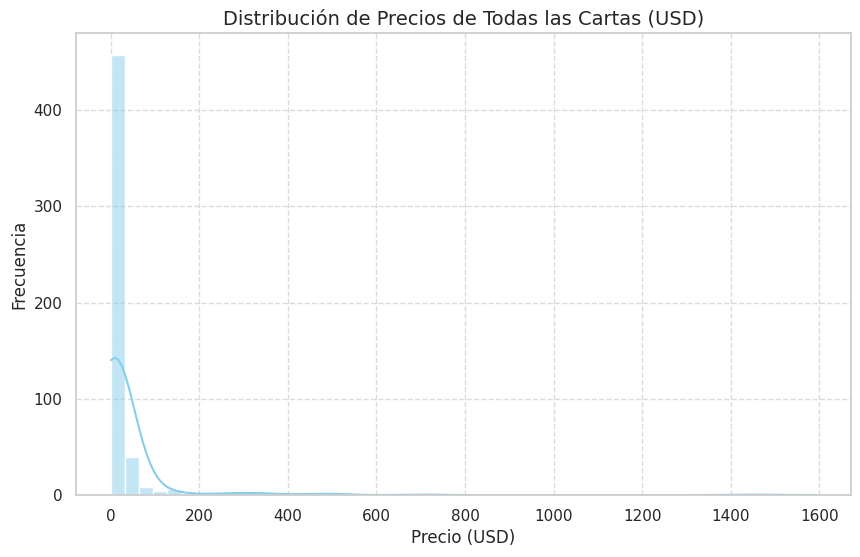

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_master['price_usd'], kde=True, bins=50, color='skyblue')
plt.title('Distribución de Precios de Todas las Cartas (USD)', fontsize=14)
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# DESCARGAR PDF

In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-latex-extra

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-jav

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/"

'11 sep #2.ipynb'
'11 sep.ipynb'
 actividad77.ipynb
 actividad77.pdf
'anALISIS NUMERICO 25 AGOSTO.ipynb'
'apuntes sustentacion modelacion.ipynb'
 avg_household_size_column.ipynb
 Correlación.ipynb
 EcuacionesDiferencialesLol.ipynb
'ExampleParcial2 (1).ipynb'
 ExampleParcial2.ipynb
'Final NoteBook Modelacion.ipynb'
'gauss_seidel_iteraciones (1).ipynb'
 gauss_seidel_iteraciones.ipynb
'INTENTO 1 PROYECTO MODELACION 2.ipynb'
'INTENTO 2 PROYECTO MODELACION 2.ipynb'
'INTENTO 3 PROYECTO MODELACION 2_files'
'INTENTO 3 PROYECTO MODELACION 2.ipynb'
'INTENTO 3 PROYECTO MODELACION 2.pdf'
'INTENTO 3 PROYECTO MODELACION 2.tex'
'Kagle 1.ipynb'
'Modelacion actividad 2.ipynb'
'MSII_Simulation1 (1).ipynb'
 MSII_Simulation1.ipynb
 MSII_Week12.ipynb
'MSII_Week2 (1) (1).ipynb'
'MSII_Week2 (1).ipynb'
 MSII_Week2.ipynb
 MS_II_Week3.ipynb
'MS_II_Week4 (1).ipynb'
 MS_II_Week4.ipynb
 MS_II_Week5.ipynb
'MSII_Week6Test (1).ipynb'
 MSII_Week6Test.ipynb
'NoteBook #1 Modelacion y Simulacion, Yenifer Leon y Jacobo L

In [ ]:
import os

notebook_path = "/content/drive/MyDrive/Colab Notebooks/PROYECTO MODELACION 2.ipynb"

# Exportación forzando la limpieza de metadatos y ocultando celdas de código
!jupyter nbconvert --to pdf "{notebook_path}" \
    --ExecutePreprocessor.allow_errors=True \
    --no-input \
    --TemplateExporter.exclude_input=True

if os.path.exists(notebook_path.replace('.ipynb', '.pdf')):
    print("\n>>> ¡Éxito! El PDF se ha generado en tu carpeta de Drive.")
else:
    print("\n>>> La exportación directa falló. Generando .tex para depuración final...")
    !jupyter nbconvert --to latex "{notebook_path}"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/PROYECTO MODELACION 2.ipynb to pdf
[NbConvertApp] Support files will be in PROYECTO MODELACION 2_files/
[NbConvertApp] Making directory ./PROYECTO MODELACION 2_files
[NbConvertApp] Writing 97601 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2296420 bytes to /content/drive/MyDrive/Colab Notebooks/PROYECTO MODELACION 2.pdf

>>> ¡Éxito! El PDF se ha generado en tu carpeta de Drive.
